## 1 Exploratieve Data Analyse

In deze sectie analyseren we de tabulaire data en de woningafbeeldingen uit de Neural Estate dataset.

**Doel van de EDA:**
- De datastructuur en datakwaliteit valideren.
- Relaties tussen `Price` en features onderzoeken.
- Datagebreken (o.a. outliers en locatieclustering) expliciet vastleggen.
- Modelimplicaties formuleren voor vervolgopdrachten.


In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.1 Data inladen


In [54]:
%pip install tensorflow --quiet

In [55]:
# Standaardbibliotheek / bestandsbeheer
from pathlib import Path

# Basis Python modules
import random

# Numeriek & data
import numpy as np
import pandas as pd

# Visualisatie
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
import seaborn as sns

# Machine Learning scikit learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# tensorflow
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf
# Afbeeldingen
from PIL import Image

# wiskunde notaties vervangen
from matplotlib.ticker import ScalarFormatter

import copy
from sklearn.metrics import mean_absolute_percentage_error

In deze cel importeren we alle libraries die we nodig heb voor de analyse, visualisaties en het controleren van afbeeldingen. Door dit direct te doen zie hoeven we dit later niet te doen wanneer we willen inalden en analyseren van de data.


In [56]:
# Consistente visualisatie-instellingen voor de hele notebook
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


Hier zetten we een vaste plotting stijl en zorgen we dat alle kolommen te zien zijn in een Pandas Dataframe. Dit zorgt ervoor dat grafieken consistent zijn door het gehele notebook en voorkomen dat belangrijke kolommen wegvallen in Dataframes.


In [57]:
# Data direct inladen vanuit CSV-bestanden
# Update het pad naar de locatie van je CSV-bestanden in Google Drive
train_df = pd.read_csv('/content/drive/MyDrive/data/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/data/test.csv')

# Basiscontrole op dimensies
print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

# Eerste visuele inspectie van trainmetadata
display(train_df.head())


Train shape: (500, 7)
Test shape: (35, 6)


,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
0,1,4,4.00,4053,33.70,-111.89,869500
1,2,4,3.00,3343,34.83,-119.03,865200
2,3,3,4.00,3923,33.77,-111.92,889000
3,4,5,5.00,4022,33.78,-111.78,910000
4,5,3,4.00,4116,33.77,-111.92,971226


In [58]:
!ls -F /content/drive/MyDrive/

'Colab Notebooks'/
'Curriculum vitae (1).gdoc'
'Curriculum vitae.gdoc'
 data/
'Documento sin título (1).gdoc'
'Documento sin título (2).gdoc'
'Documento sin título (3).gdoc'
'Documento sin título (4).gdoc'
'Documento sin título (5).gdoc'
'Documento sin título (6).gdoc'
'Documento sin título (7).gdoc'
'Documento sin título.gdoc'
'give me a plan. (i train on boxing gym monday 19:....gdoc'
'Google AI Studio'/
'Inhoud poster.gdoc'
'maak de volgende inhoudsopgave in word:'$'\n\n''Inhoudso....gdoc'
'should a boxer use creatine if he want to go seri....gsheet'
'welke cijfer zou je even.gsheet'


Deze cel leest en laad de train en test data direct uit de CSV bestanden. Daarna kijken we naar de shapes en de eerste paar rijen om de bestanden kort te bekijken en te controleren dat alles er goed uit ziet.

### 1.2 Datakwaliteit tabulaire data


In [59]:
def quality_report(df: pd.DataFrame) -> dict:
    '''Maak een compact datakwaliteitsrapport voor een DataFrame.'''
    # Verzamel alle data quality checks in een rapport dictionary om later te printen
    report = {
        'shape': df.shape,
        'columns': list(df.columns),
        'dtypes': df.dtypes.astype(str).to_dict(),
        'missing_values': df.isna().sum().to_dict(),
        'duplicate_rows': int(df.duplicated().sum()),
        # House ID hoort uniek te zijn. duplicates kunnen label/image-koppeling breken
        'duplicate_house_id': int(df['House ID'].duplicated().sum()) if 'House ID' in df.columns else None,
    }
    return report


def print_quality_report(name: str, report: dict) -> None:
    '''Print het kwaliteitsrapport in een leesbaar formaat.'''
    print(f'\n | {name} | ')
    print(f"Shape: {report['shape']}")
    print(f"Kolommen: {report['columns']}")
    print('Dtypes:')
    print(pd.Series(report['dtypes']))
    print('Missing values per kolom:')
    print(pd.Series(report['missing_values']))
    print(f"Duplicate rows: {report['duplicate_rows']}")
    print(f"Duplicate House ID: {report['duplicate_house_id']}")


In deze cel maak ik snelle help functies aan om een snelle inzicht te krijgen van de kwaliteit van de dataset, zoals missende waardes en basisstatistieken. Ik zet dit in een eigen cel omdat het netter is en het houdt alles overzichtelijk. Ook maakt dit het herhaalbaar.


In [60]:
# Kwaliteitsrapporten genereren
train_quality = quality_report(train_df)
test_quality = quality_report(test_df)

# Resultaten overzichtelijk printen
print_quality_report('Train', train_quality)
print_quality_report('Test', test_quality)



 | Train | 
Shape: (500, 7)
Kolommen: ['House ID', 'Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude', 'Price']
Dtypes:
House ID       int64
Bedrooms       int64
Bathrooms    float64
Area           int64
Latitude     float64
Longitude    float64
Price          int64
dtype: object
Missing values per kolom:
House ID     0
Bedrooms     0
Bathrooms    0
Area         0
Latitude     0
Longitude    0
Price        0
dtype: int64
Duplicate rows: 0
Duplicate House ID: 0

 | Test | 
Shape: (35, 6)
Kolommen: ['House ID', 'Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude']
Dtypes:
House ID       int64
Bedrooms       int64
Bathrooms    float64
Area           int64
Latitude     float64
Longitude    float64
dtype: object
Missing values per kolom:
House ID     0
Bedrooms     0
Bathrooms    0
Area         0
Latitude     0
Longitude    0
dtype: int64
Duplicate rows: 0
Duplicate House ID: 0


Hier doen we basic EDA op zowel `train_df` als `test_df` en laten we de resultaten overzichtelijk zien. We maken een rapport dat in een keer de shape, kolommen, data types, missing values en duplicate values weergeeft.


### 1.3 Target-analyse (`Price`)

We verwijderen outliers nog niet uit de basisdataset.


In [61]:
def target_report(df: pd.DataFrame, target_col: str = 'Price') -> dict:
    '''Analyseer targetverdeling, scheefheid en outliers op target en prijs per sqft.'''
    if target_col not in df.columns:
        raise ValueError(f"Kolom '{target_col}' zit niet in df.")

    # Targetkolom selecteren
    y = df[target_col]

    # IQR-outlierdetectie:
    # IQR = Q3 - Q1
    # Ondergrens = Q1 - 1.5*IQR
    # Bovengrens = Q3 + 1.5*IQR
    q1 = float(y.quantile(0.25))
    q3 = float(y.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (y < lower) | (y > upper)

    report = {
        'describe': y.describe().to_dict(),
        'skew_price': float(y.skew()),
        'iqr_bounds_price': (float(lower), float(upper)),
        'n_outliers_price': int(outlier_mask.sum()),
        'outlier_house_ids': df.loc[outlier_mask, 'House ID'].tolist() if 'House ID' in df.columns else [],
    }

    # Extra outlieranalyse op prijs per square foot voor detectie van onrealistische waarderingen
    if 'Area' in df.columns:
        price_per_square_feet = y / df['Area']
        price_q1, price_q3 = price_per_square_feet.quantile([0.25, 0.75])
        price_iqr = price_q3 - price_q1
        price_lower, price_upper = price_q1 - 1.5 * price_iqr, price_q3 + 1.5 * price_iqr
        price_outlier_mask = (price_per_square_feet < price_lower) | (price_per_square_feet > price_upper)

        report['price_per_sqft_describe'] = price_per_square_feet.describe().to_dict()
        report['iqr_bounds_price_per_sqft'] = (float(price_lower), float(price_upper))
        report['n_outliers_price_per_sqft'] = int(price_outlier_mask.sum())
        report['ppsf_outlier_house_ids'] = df.loc[price_outlier_mask, 'House ID'].tolist() if 'House ID' in df.columns else []

    return report

In [62]:
def plot_target_analysis(df: pd.DataFrame, target_col: str = 'Price') -> None:
    '''Toon target-distributies: raw, zoomed en log1p.'''
    y = df[target_col]
    y_log = np.log1p(y)

    # Zelfde IQR bovengrens gebruiken voor een leesbare zoomed plot
    q1, q3 = y.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # Raw distributie in de plot voegen
    sns.histplot(y, bins=35, kde=True, ax=axes[0, 0], color='#1f77b4')
    axes[0, 0].set_title('Price distributie (raw)')
    axes[0, 0].set_xlabel('Price (USD)')

    # Raw boxplot voor snelle outlierdetectie zonder zoom in de plot voegen
    sns.boxplot(x=y, ax=axes[0, 1], color='#ff7f0e')
    axes[0, 1].set_title('Price boxplot (raw)')
    axes[0, 1].set_xlabel('Price (USD)')

    # Zoomed distributie om outliers van dichterbij te bekijken
    sns.histplot(y[y <= upper], bins=35, kde=True, ax=axes[1, 0], color='#2ca02c')
    axes[1, 0].set_title('Price distributie (zoomed, top outliers gefilterd in plot)')
    axes[1, 0].set_xlabel('Price (USD)')

    # log1p distributie om scheefbaarheid zichtbaar te maken
    sns.histplot(y_log, bins=35, kde=True, ax=axes[1, 1], color='#9467bd')
    axes[1, 1].set_title('Price distributie (log1p)')
    axes[1, 1].set_xlabel('log1p(Price)')

    plt.tight_layout()
    plt.show()

Deze cel bevat functies die specifiek de target `Price` analyseren, bijvoorbeeld verdeling en basiskenmerken. Het doel is om target patronen te begrijpen, zodat we betere keuzes kunnen maken voor preprocessing en model aanpak.


Target report (samenvatting):
Skew Price: 3.613
Price outliers (IQR): 23
Price per sqft outliers (IQR): 24
Price IQR bounds: (-536000.0, 1520000.0)


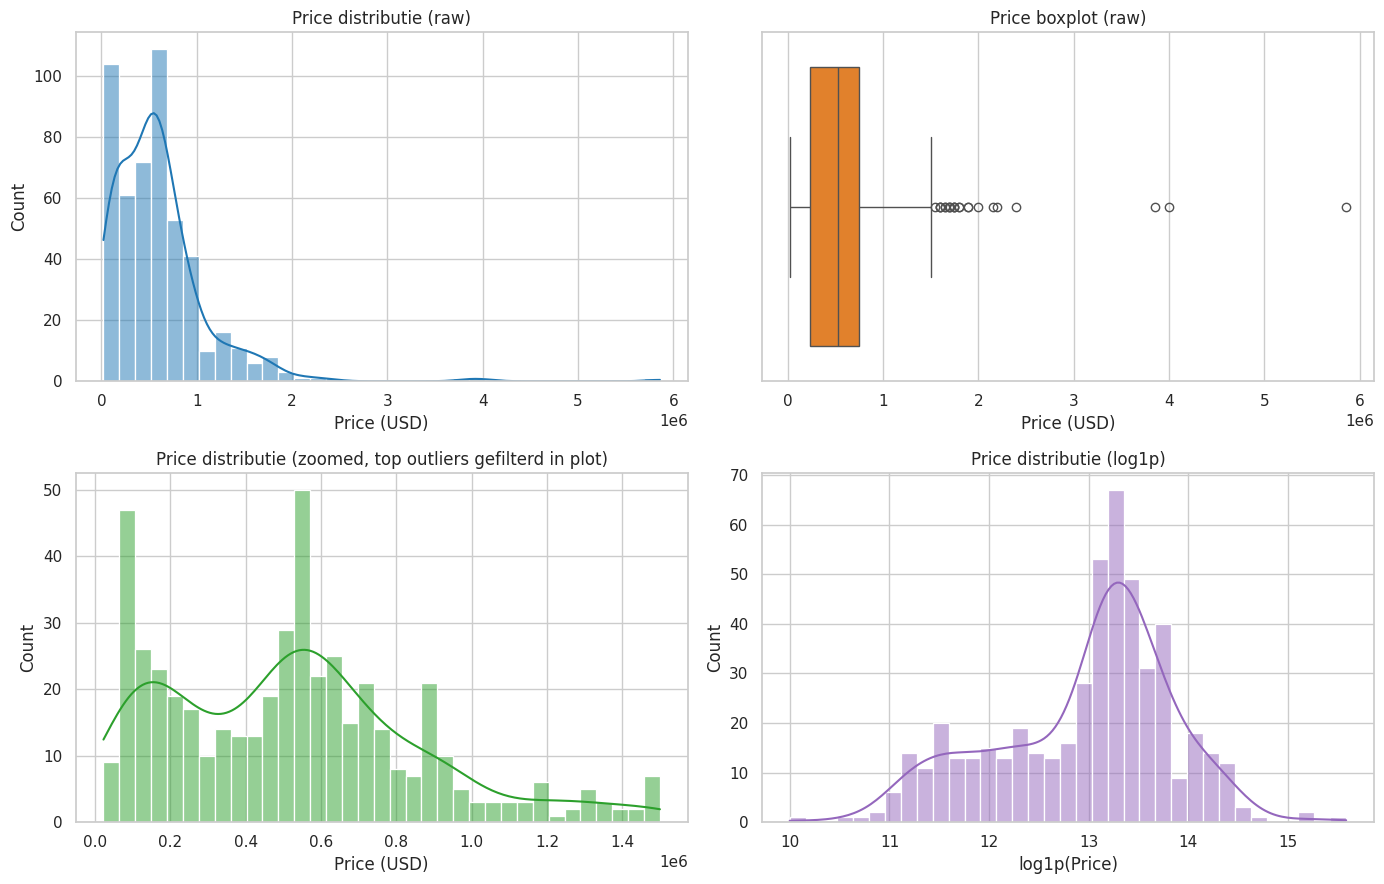

In [63]:
# Targetrapport opbouwen met gebruik van eerder gebouwde functie
target_stats = target_report(train_df)

# Kerncijfers printen voor snelle rapportage in tekst
print('Target report (samenvatting):')
print(f"Skew Price: {target_stats['skew_price']:.3f}")
print(f"Price outliers (IQR): {target_stats['n_outliers_price']}")
print(f"Price per sqft outliers (IQR): {target_stats.get('n_outliers_price_per_sqft', 'n.v.t.')}")
print(f"Price IQR bounds: {target_stats['iqr_bounds_price']}")

# Visualisaties maken met gebruik van eerder gebouwde functie
plot_target_analysis(train_df)


Hier voeren we de target-analyse uit op `train_df` en maken we visualisaties om de distributie en de outliers te bekijken. Dit helpt ons om snel te zien of `Price` scheef verdeeld is, extreme waarden bevat, of een transformatie logisch is en ons helpt.


### 1.4 Relaties tussen features en target


In [64]:
def feature_target_plots(df: pd.DataFrame, target_col: str = 'Price') -> pd.Series:
    '''Visualiseer feature target relaties (raw en zoomed) en correlaties.'''
    features = ['Area', 'Bathrooms', 'Bedrooms']

    # Consistente IQR bovengrens voor zoomed weergaves
    q1, q3 = df[target_col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    zoom_df = df[df[target_col] <= upper].copy()

    # Formatter zonder wetenschappelijke notatie
    plain_formatter = ScalarFormatter(useOffset=False)
    plain_formatter.set_scientific(False)

    # Bovenste rij: raw, onderste rij: zoomed
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for idx, feature in enumerate(features):
        sns.scatterplot(data=df, x=feature, y=target_col, alpha=0.6, ax=axes[0, idx], color='#1f77b4')
        axes[0, idx].set_title(f'{feature} vs {target_col} (raw)')

        sns.scatterplot(data=zoom_df, x=feature, y=target_col, alpha=0.6, ax=axes[1, idx], color='#2ca02c')
        axes[1, idx].set_title(f'{feature} vs {target_col} (zoomed)')

        # Volledige getallen op beide assen tonen
        for row in range(2):
            axes[row, idx].yaxis.set_major_formatter(plain_formatter)
            axes[row, idx].xaxis.set_major_formatter(plain_formatter)
            axes[row, idx].ticklabel_format(style='plain', axis='both')

    plt.tight_layout()
    plt.show()

    # Correlatiematrix over alle numerieke kolommen
    numeric_cols = df.select_dtypes(include=np.number).columns
    corr_matrix = df[numeric_cols].corr(numeric_only=True)

    # Heatmap toont lineaire samenhang, geen causaliteit
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlatie-heatmap (numerieke kolommen)')
    plt.tight_layout()
    plt.show()

    # Return gesorteerde correlaties met target voor tekstsamenvatting
    corr_with_target = corr_matrix[target_col].sort_values(ascending=False)
    return corr_with_target


In deze cel maken we functies aan om de relaties tussen features en `Price` te onderzoeken door gebruik te maken van plots en correlaties. Zo kunnen we later dezelfde code gebruiken zonder telkens dezelfde plotting code te herhalen.


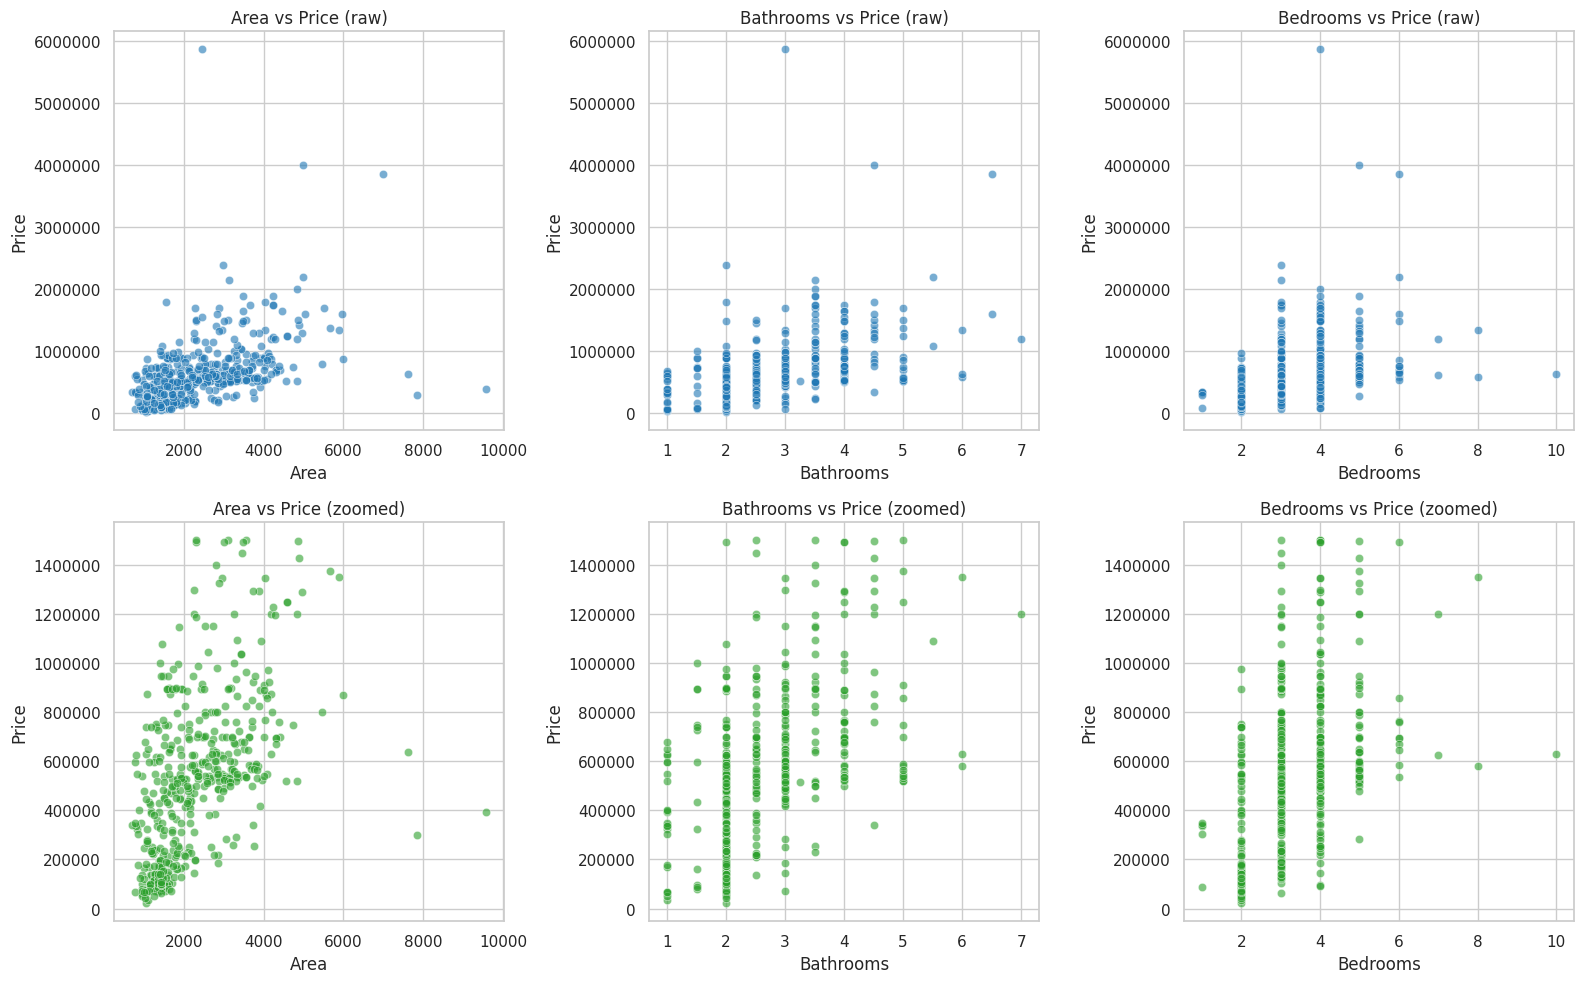

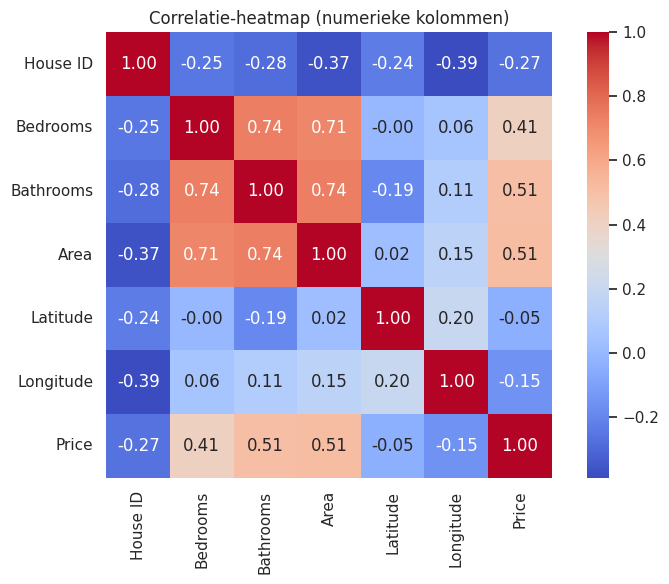

Correlatie met Price:
Price        1.00
Area         0.51
Bathrooms    0.51
Bedrooms     0.41
Latitude    -0.05
Longitude   -0.15
House ID    -0.27
Name: Price, dtype: float64


In [65]:
# scatter plot en correlaties met Price maken
corr_with_price = feature_target_plots(train_df)

# Gesorteerde correlaties met price printen voor directe rapportage
print('Correlatie met Price:')
print(corr_with_price)


Deze cel draait de feature target analyse op de trainingsdata en geeft een eerste indicatie welke features mogelijk informatief zijn


### 1.5 Geografische patronen


In [66]:
def geo_analysis(df: pd.DataFrame) -> dict:
    '''Analyseer locatieclustering en prijsvariatie per geolocatie.'''
    # Frequentie per unieke Latitude, Longitude combinatie
    geo_counts = df.groupby(['Latitude', 'Longitude']).size().sort_values(ascending=False)
    unique_geo = int(geo_counts.shape[0])

    # Prijsstatistiek maken voor de meest voorkomende locaties
    spread = (
        df.groupby(['Latitude', 'Longitude'])['Price']
        .agg(['count', 'median', 'min', 'max'])
        .sort_values('count', ascending=False)
        .head(10)
    )

    # Geografische spreiding visualiseren waarbij de kleur prijsniveau representeert
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        df['Longitude'],
        df['Latitude'],
        c=df['Price'], #colour
        cmap='viridis',
        alpha=0.75,
        s=40, #size
        edgecolor='k',
        linewidth=0.2,
    )
    plt.colorbar(scatter, label='Price (USD)')
    plt.title('Geografische spreiding van woningen (kleur = Price)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

    report = {
        'unique_geolocations': unique_geo,
        'total_rows': int(len(df)),
        'top_geo_counts': geo_counts.head(10),
        'top_geo_price_spread': spread,
    }
    return report


Hier definieren we functies om geografische patronen in de data te analyseren, bijvoorbeeld clustering of verschillen per locatie. Locatie is vaak een sterke driver voor prijs en kan ook voor outliers zorgen.


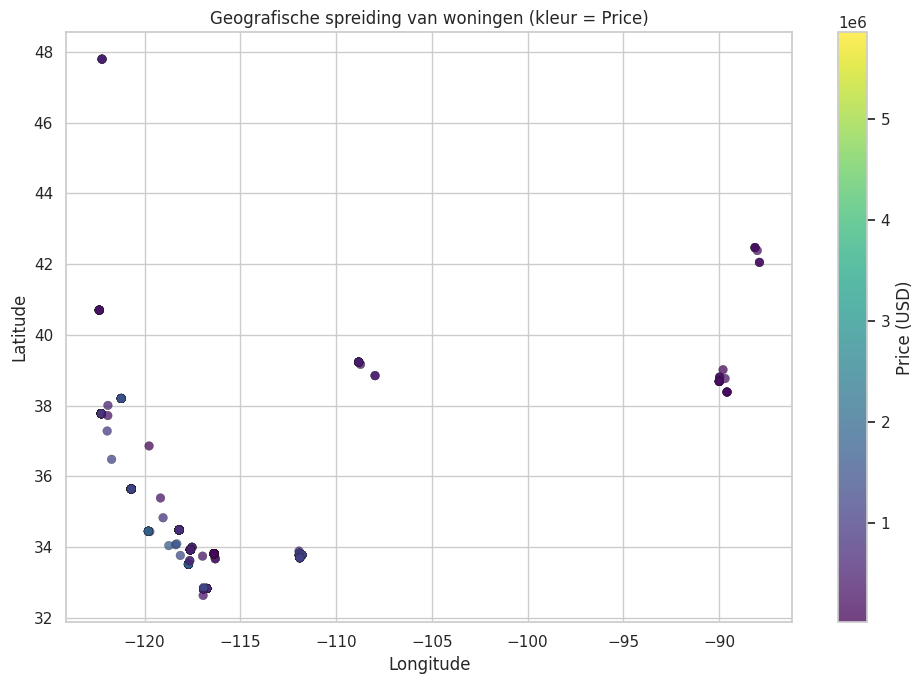

,kenmerk,waarde
0,unieke geolocaties,47
1,totaal rijen,500


,Latitude,Longitude,frequentie
0,33.81,-116.37,100
1,34.48,-118.20,60
2,35.64,-120.70,50
3,33.92,-117.61,49
4,37.77,-122.26,41
5,32.83,-116.75,32
6,33.51,-117.71,26
7,33.70,-111.89,12
8,40.70,-122.37,12
9,34.45,-119.80,11


,Latitude,Longitude,count,median,min,max
0,33.81,-116.37,100,"105,475.00",36000,385000
1,34.48,-118.20,60,"549,475.00",195000,5858000
2,35.64,-120.70,50,"504,750.00",125000,2395000
3,33.92,-117.61,49,"539,800.00",448000,749000
4,37.77,-122.26,41,"749,000.00",339000,1895000
5,32.83,-116.75,32,"684,000.00",65000,1499000
6,33.51,-117.71,26,"882,000.00",324999,3850000
7,33.70,-111.89,12,"1,039,000.00",500000,1749000
8,40.70,-122.37,12,"239,900.00",22000,1795000
9,34.45,-119.80,11,"1,149,000.00",599999,4000000


In [67]:
# Geo analyse uitvoeren
geo_report = geo_analysis(train_df)

# Samenvatting als DataFrame opslaan
geo_summary_df = pd.DataFrame({
    'kenmerk': ['unieke geolocaties', 'totaal rijen'],
    'waarde': [geo_report['unique_geolocations'], geo_report['total_rows']],
})

# Top geolocaties op frequentie als DataFrame opslaan
top_geo_counts_df = (
    geo_report['top_geo_counts']
    .rename('frequentie')
    .reset_index()
)

# Prijs range voor de top geolocaties als DataFrame opslaan
top_geo_price_spread_df = geo_report['top_geo_price_spread'].reset_index()

display(geo_summary_df)
display(top_geo_counts_df)
display(top_geo_price_spread_df)

In deze cel doen we geo analyse uit op `train_df` en tonen we de vindingen die we hebben.

Het doel van deze analyse was om te begrijpen of locatie speciale behandelingen nodig hebben en of er enige patronen zijn die het model nodig heeft om beter te presteren.

- We hebben 47 unieke geolocaties gevonden voor 500 rijen. Dit betekent dat er veel duplicate coordinaten zijn. Het betekent ook data er grote prijs spreidingen zijn in dezelfde locaties, wat vreemd is. Dit is iets waar we extra onderzoek naar moeten doen omdat het betekent dat longitude en latitude goeie informatie geven, maar niet genoeg zijn voor accurate voorspellingen. Image data kan extra informatie geven waarom de prijzen zo versvhillend zijn bij dezelfde locatie cluster.


### 1.6 Beelddata-validatie en sample-visualisatie


In [68]:
def validate_image_folder(image_folder_path: Path, expected_image_count: int) -> dict:
    '''Controleer aantal beelden, formaat, modus en corrupte bestanden.'''
    # Verzamel alle jpg-bestanden uit de gekozen map en zet ze in een vaste volgorde
    image_files = sorted(image_folder_path.glob('*.jpg'))

    # In deze lists slaan we de gevonden eigenschappen van de images op
    image_sizes = []
    image_modes = []
    corrupted_files = []

    # Loop door alle images om te kijken of ze goed openen
    for image_path in image_files:
        try:
            # Open de image en bewaar basisinformatie zoals grootte en kleurmodus
            with Image.open(image_path) as image:
                image_sizes.append(image.size)
                image_modes.append(image.mode)
        except Exception:
            # Als een image niet geopend kan worden, markeren we die als corrupt
            corrupted_files.append(image_path.name)

    # Maak een compact rapport met technische controles
    report = {
        'folder': str(image_folder_path),
        'expected_count': expected_image_count,
        'actual_count': len(image_files),
        'count_match': len(image_files) == expected_image_count,
        'unique_sizes': sorted(set(image_sizes)),
        'unique_modes': sorted(set(image_modes)),
        'corrupted_files': corrupted_files,
    }
    return report


def compare_csv_image_ids(metadata_df: pd.DataFrame, image_folder_path: Path) -> dict:
    '''Controleer of House ID waarden in CSV overeenkomen met image bestandsnamen.'''
    # Haal alle House ID's uit de metadata zodat we weten welke images er zouden moeten zijn
    csv_house_ids = set(metadata_df['House ID'].astype(int).tolist())

    # Haal alle House ID's uit de bestandsnamen van de images
    # Voorbeeld: 123.jpg wordt omgezet naar House ID 123
    image_house_ids = {
        int(image_path.stem)
        for image_path in image_folder_path.glob('*.jpg')
        if image_path.stem.isdigit()
    }

    # Vergelijk beide collections om te zien welke koppelingen we missen en welke extra images er zijn
    return {
        'csv_minus_images': sorted(csv_house_ids - image_house_ids),
        'images_minus_csv': sorted(image_house_ids - csv_house_ids),
    }

In [69]:
def show_image_samples(image_folder_path: Path, sample_count: int = 8, random_seed: int = 42) -> None:
    '''Toon representatieve random samples uit een map met woningimages.'''
    # Verzamel alle beschikbare image paths uit de map
    image_paths = sorted(image_folder_path.glob('*.jpg'))

    # Zorgen dat we nooit meer images proberen te tonen dan er ook werkelijk zijn
    if sample_count > len(image_paths):
        sample_count = len(image_paths)

    # Gebruik een vaste seed zodat steeds dezelfde voorbeelden gekozen worden
    random_generator = random.Random(random_seed)
    sampled_image_paths = random_generator.sample(image_paths, sample_count)

    # Bepaal hoe groot het image raster moet zijn
    column_count = 4
    row_count = int(np.ceil(sample_count / column_count))
    fig, axes = plt.subplots(row_count, column_count, figsize=(16, 4 * row_count))
    axes = np.array(axes).reshape(-1)

    # Zet alle assen standaard uit zodat alleen de images zichtbaar zijn
    for axis in axes:
        axis.axis('off')

    # Laat de gekozen images zien met hun House ID als titel
    for axis, image_path in zip(axes, sampled_image_paths):
        with Image.open(image_path) as image:
            axis.imshow(image)
            axis.set_title(f'House ID: {image_path.stem}')
            axis.axis('off')

    # toevoegen van titel voor het volledige overzicht
    plt.suptitle('Representatieve samples uit Train', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

Deze cellen definieert functies om te controleren of de image mappen kloppen met de CSV's, en om later snel voorbeelden te kunnen tonen. Ook hier scheiden dit van de rest zodat validatie en visualisatie herhaalbaar blijven


'Train image report:'

{'folder': '/content/drive/MyDrive/data/Train',
 'expected_count': 500,
 'actual_count': 500,
 'count_match': True,
 'unique_sizes': [(1024, 1024)],
 'unique_modes': ['RGB'],
 'corrupted_files': []}

'Test image report:'

{'folder': '/content/drive/MyDrive/data/Test',
 'expected_count': 35,
 'actual_count': 35,
 'count_match': True,
 'unique_sizes': [(1024, 1024)],
 'unique_modes': ['RGB'],
 'corrupted_files': []}

'Train CSV/Image ID check:'

{'csv_minus_images': [], 'images_minus_csv': []}

'Test CSV/Image ID check:'

{'csv_minus_images': [], 'images_minus_csv': []}

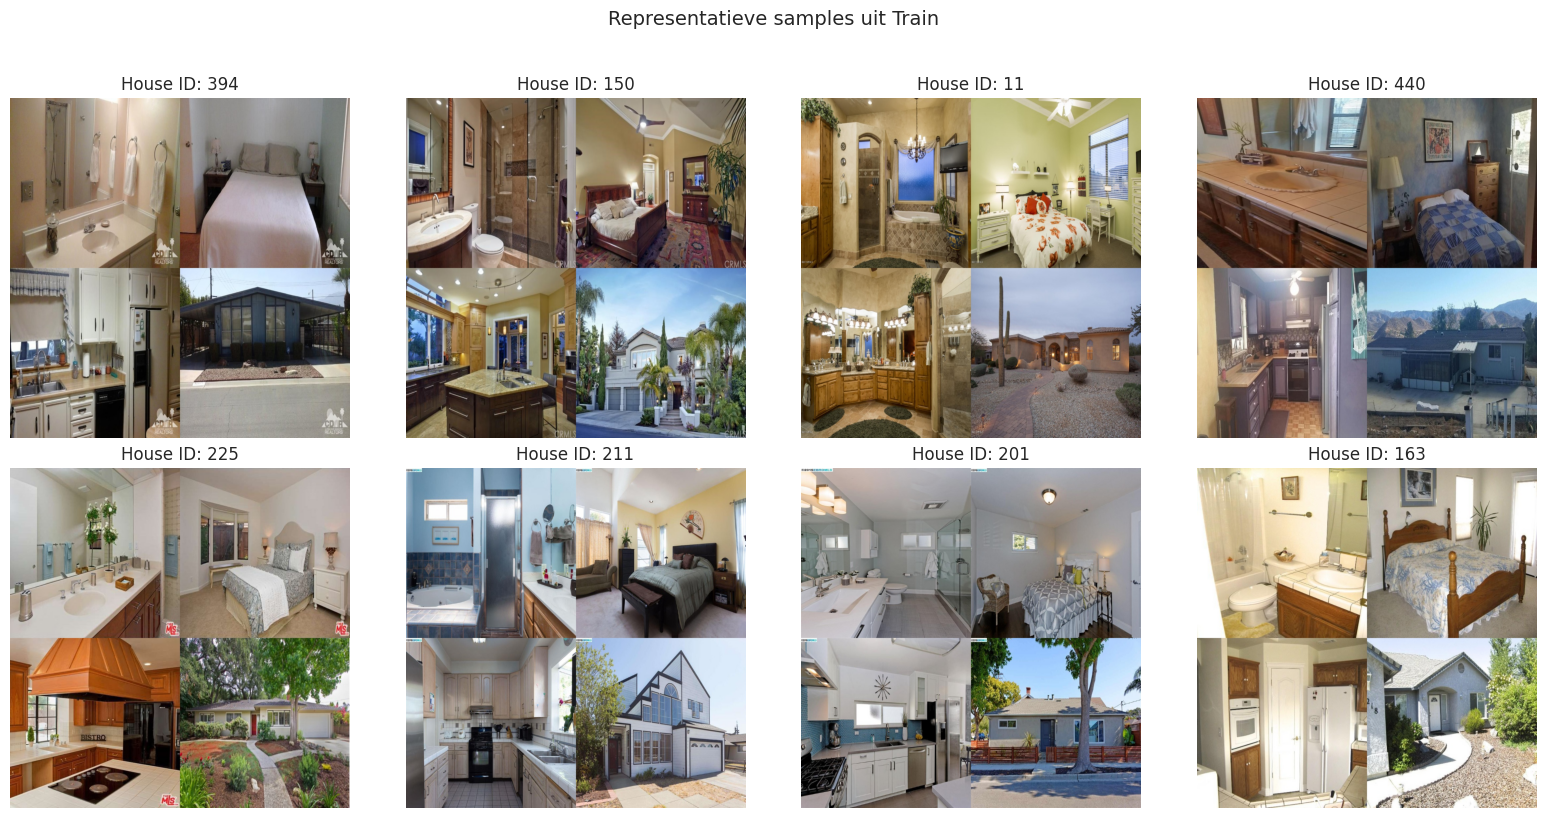

In [70]:
#  validatie van train en test beeld mappen
train_img_report = validate_image_folder(Path('/content/drive/MyDrive/data/Train'), expected_image_count=len(train_df))
test_img_report = validate_image_folder(Path('/content/drive/MyDrive/data/Test'), expected_image_count=len(test_df))

# Controle of CSV ID's en image ID's wel overeenkomen
train_id_check = compare_csv_image_ids(train_df, Path('/content/drive/MyDrive/data/Train'))
test_id_check = compare_csv_image_ids(test_df, Path('/content/drive/MyDrive/data/Test'))

# Resultaten printen voor rapportage
display('Train image report:', train_img_report)
display('Test image report:', test_img_report)
display('Train CSV/Image ID check:', train_id_check)
display('Test CSV/Image ID check:', test_id_check)

# Visuele kwaliteitscheck met reproduceerbare samplebeelden
show_image_samples(Path('/content/drive/MyDrive/data/Train'), sample_count=8, random_seed=42)


Hier controleren we de train en testbeeldmappen tegen de metadata en kijken we naar een paar voorbeeld images. Dit doen we omdat we zeker willen zijn dat de IDs matchen en dat de images leesbaar zijn voordat we een computer vision model gaan trainen.


### 1.7 Belangrijkste bevindingen en implicaties

**Belangrijkste EDA-bevindingen**
- De metadata is schoon: geen missende waarden, geen duplicate rows en geen duplicate `House ID`.
- Beelddata is consistent: aantallen kloppen met CSV, geen corrupte afbeeldingen, uniform formaat (`1024x1024`, RGB).
- `Price` is sterk rechts-scheef verdeeld.
- Sterkste lineaire verbanden met `Price` zitten in `Area`, `Bathrooms` en `Bedrooms`.
- Er zijn duidelijke prijs en prijs per vierkante voet outliers. Deze zijn **niet verwijderd**.
- Locatiegegevens zijn sterk geclusterd (relatief weinig unieke coordinaten t.o.v. aantal woningen), met grote prijsvariatie binnen dezelfde locatie.
- `House ID` correleert met `Price`, maar is een identifier en wordt in modellering niet als feature gebruikt.
- `House ID` is geexcludeerd omdat het een identifier is en geen belangrijke voorspeller.

# 2 Fully-connected neuraal netwerk

### 2.1 Fully connected netwerk bouwen
In deze deelopdracht bouwen we een fully-connected neuraal netwerk om huizenprijzen te voorspellen op basis van tabulaire metadata. We gebruiken de volgende invoer variabelen:
- Bedrooms
- Bathrooms
- Area
- Latitude
- Longitude

De kolom House ID wordt niet meegenomen, omdat dit alleen een identifier is en geen inhoudelijke eigenschap van een woning.

Uit de EDA bleek dat Price sterk rechts-scheef verdeeld is en outliers bevat. Daarom gebruiken we:
- log1p(Price) als targettransformatie
- Huber loss als lossfunctie
- feature scaling met StandardScaler

### 2.2 Reproduceerbaarheid

In [71]:
# Zet vaste seeds zodat resultaten van deze sectie reproduceerbaar blijven.
np.random.seed(42)
tf.random.set_seed(42)

**Toelichting**

Hier hebben we vaste random seeds voor python numpy en pytorch aangemaakt. Daardoor blijft het trainen nvan het netwerk reproduceerbaar en kunnen we efficient en snel verschillende experimenten doen en ze met elkaar vergelijken.  
We zorgen voor een stabiele omgeving als basis voor onze model

### 2.3 Data voorbereiden

In [72]:
# Features en target
feature_cols = ['Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude']
target_col = 'Price'

# kopieen maken zodat veranderingen de originele DataFrame niet aantasten
X = train_df[feature_cols].copy()
y = train_df[target_col].copy()

# Log-transformatie van target omdat rechts-scheve verdeling
y_log = np.log1p(y)

**Toelichting**

Hier selecteren we de 5 metadatafeatures die we gebruiken als input voor het model en zetten we de target als `Price`. We transformeren de target met `log1p` zodat het niet getrained wordt op de extreem rechts scheve verdeling. Uitschieters beinvloeden het model en dit limiteerd dat de werkelijke patronen die het model moet leren worden beinvloed door deze uitschieters.

### 2.4 Train/validatie split en scaling

In [73]:
# Splitsing van de tabulaire features en de gelogde target in train en validatie sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# We fitten de scaler alleen op de trainingsdata om datalekken te voorkomen gebruiken dezelfde schaal voor validatie
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

**Toelichting**

Deze cel splitst de data op in trainings en validatie delen en schaalt de features met `StandardScaler`. de scaler wordt alleen op de trainingsdata gefit en daarna toegepast op de validatieset.
Dit doen we om datalek in de validatieset te voorkomen.
Als we scaler op alle data tegelijk zouden fitten zou informatie uit de validatieset al in de trainings proces terechtkomen.

We proberen een eeerlijke train en validatie verdeling te maken en goed geschaalde inputs te krijgen zodat het nwetwerk stabieler en beter getrained wordt.

### 2.5 Voorbereiden van data voor TensorFlow/Keras
Na het schalen zetten we de data om naar `float32` arrays die direct bruikbaar zijn in `tf.keras`. Daarmee kunnen we de verschillende netwerkvarianten op exact dezelfde split vergelijken.


In [74]:
# Zet de geschaalde features en targets om naar float32 arrays voor TensorFlow en Keras.
X_train_tf = X_train_scaled.astype(np.float32)
X_val_tf = X_val_scaled.astype(np.float32)

y_train_tf = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
y_val_tf = y_val.to_numpy(dtype=np.float32).reshape(-1, 1)

print(f'X_train_tf shape: {X_train_tf.shape}')
print(f'X_val_tf shape: {X_val_tf.shape}')
print(f'y_train_tf shape: {y_train_tf.shape}')
print(f'y_val_tf shape: {y_val_tf.shape}')


X_train_tf shape: (400, 5)
X_val_tf shape: (100, 5)
y_train_tf shape: (400, 1)
y_val_tf shape: (100, 1)


**Toelichting**

Deze. codecel zet de scaled numpy array om naar float32 arrays. Dit is zodat ze direct in tf.keras gebruikt kunnen worden. Daardoorr kunnen we het model straks trainen met model.fit() en valideren met validation_data = (X_val_tf, y_val_tf).

Keras werkt goed met numpy arrays en dit is simpel.

Hiermee proberen we de tabulaire data in een vorm te brengen waar direct mee werkbaar is voor TensorFlow/Keras

### 2.6 Model maken
We kiezen voor een dense structuur 64 -> 32 -> 16 -> 1. Wij denken dat een groot genoeg structuur moet. zijn om non-linear relaties te leren en voorspellingen accuraat te kunnen maken.

In de hidden layers gebruiken we Relu. Relu is efficient en werkt goed met tabulaire neural networks. De outplay layer heeft geen activationfunctie. Dit hebben we weggelaten zodat het model vrij en continu een numerieke waarde kan voorspellen

We vergelijken varianten met dropout en varianten zonder dropout omdat wij denken dat dropout niet zo goed zal helpen bij deze dataset, maar toch testen we dit.


In [75]:
# Bouw een compact neuraal netwerk voor het voorspellen van huizenprijzen.
# Het model voorspelt één continue waarde op basis van 5 input features.
def build_house_price_model(use_dropout=True, dropout_first=0.2, dropout_second=0.1):
    # Start met een lijst van layers waaruit het Sequential model wordt opgebouwd.
    layers = [
        # input layer aanmaken met 5 numeriek features.
        tf.keras.layers.Input(shape=(5,)),

        # Eerste hidden layer
        tf.keras.layers.Dense(64, activation='relu'),
    ]

    # Voeg optioneel dropout toe na de eerste Dense layer.
    # Dropout zet tijdens training willekeurig een deel van de neuronen uit om overfitting te voorkomen.
    if use_dropout:
        layers.append(tf.keras.layers.Dropout(dropout_first))

    # tweede hidden layer.
    layers.extend([
        tf.keras.layers.Dense(32, activation='relu'),
    ])

    # Voeg optioneel een tweede dropout toe na de tweede Dense layer.
    if use_dropout:
        layers.append(tf.keras.layers.Dropout(dropout_second))

    # de laatste hidden layer en output layer
    layers.extend([
        # Derde hidden layer
        tf.keras.layers.Dense(16, activation='relu'),

        # Output layer
        tf.keras.layers.Dense(1),
    ])

    # aanmaken en returnen van Sequential model.
    return tf.keras.Sequential(layers, name='house_price_nn')


sample_model = build_house_price_model(use_dropout=False)

# samenvatting van het model:
sample_model.summary()

Model: "house_price_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

**Toelichting**

Deze codecel definieert een functie build_house_price_model, die een fully connected neuraal netwerk bouwt met 3 hidden layers en een lineaire regression output layer. We voegen dropout optioneel toe om voor het geval van overfitting dit te verminderen.

We doen dit op deze manier omdat de dataset klein is. Er zijn maar 5 numerical input features. De structuur die wij hier hebben genomen is genoeg om non-lineair patronen/relaties te leren maar ook klein genoeg om niet te overfitten op de dataset.

We zetten dit in functies zodat we dit later kunnen hergebruiken mocht dit nodig zijn. Zo kunnen we makkelijk experimenteren, trainen en vergelijken.

### 2.7 Loss en optimizer
Voor regressie kijken we naar twee loss functions: tf.keras.losses.Huber() en tf.keras.losses.MeanSquaredError().

Huber kijken we naar omdat de EDA liet zien dat de prijsverdeling scheef is en dat er uitschieters zijn. MeanSquaredError straft grote fouten extra zwaar af. MAE is robuuster tegen uitschieters, maar moeilijker te optimaliseren is.

Als optimisers gebruiken we tf.keras.optimizers.Adam. Adam past de learning rate per parameter op adaptieve wijze aan op bases van lopende gemiddelden van gradients en gekwadrateerde gradients.


In [76]:
# Leg de vier experimentvarianten vast die we onder identieke omstandigheden vergelijken.
experiment_configs = [
    {
        'name': 'Huber + dropout',
        'loss_name': 'huber',
        'loss_label': 'Huber loss',
        'use_dropout': True,
    },
    {
        'name': 'Huber zonder dropout',
        'loss_name': 'huber',
        'loss_label': 'Huber loss',
        'use_dropout': False,
    },
    {
        'name': 'MSE + dropout',
        'loss_name': 'mse',
        'loss_label': 'MSE loss',
        'use_dropout': True,
    },
    {
        'name': 'MSE zonder dropout',
        'loss_name': 'mse',
        'loss_label': 'MSE loss',
        'use_dropout': False,
    },
]

# Zet de configuraties in een tabel zodat de varianten eenvoudig te vergelijken zijn.
pd.DataFrame(experiment_configs)

,name,loss_name,loss_label,use_dropout
0,Huber + dropout,huber,Huber loss,True
1,Huber zonder dropout,huber,Huber loss,False
2,MSE + dropout,mse,MSE loss,True
3,MSE zonder dropout,mse,MSE loss,False


### 2.8 Training van model
we hebben gekozen voor 200 epochs. Tegelijkertijd gebruiken we early stopping, zodat de training automatisch stopt zodra de validatieloss niet meer verbetert. Dit vermindert ook direct overfitting.

In [77]:
# Functie om evaluatiemetrics te berekenen op de originele schaal van de huisprijzen
def compute_metrics(y_true, y_pred):
    return {
        # MAPE is het gemiddelde procentuele fout
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),

        # MAE is het gemiddelde absolute fout
        "MAE": mean_absolute_error(y_true, y_pred),

        # RMSE is de wortel van de gemiddelde kwadratische fout
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),

        # R2 is de verklaarde variantie
        "R2": r2_score(y_true, y_pred),
    }


# Functie om 1 volledige experiment run uit te voeren
# hier bouwen we het model, trainen we het, maken we voorspellingen en
# rekenen we metrics uit
def run_experiment(config):

    # TensorFlow sessie clearen om geheugen te besparen en overlap voorkomen
    tf.keras.backend.clear_session()

    # random seed vastzetten voor reproduceerbaarheid
    tf.keras.utils.set_random_seed(42)

    # Bouw model op basis van: of met of zonder dropout
    model = build_house_price_model(use_dropout=config["use_dropout"])

    # Kies loss functie afhankelijk van config:
    # Huber is robuuster tegen outliers en MSE is de standaard regressie loss
    loss_function = (
        tf.keras.losses.Huber()
        if config["loss_name"] == "huber"
        else tf.keras.losses.MeanSquaredError()
    )

    # model compilen met Adam optimizer
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_function,
    )

    # EarlyStopping gebruiken om overfitting te voorkomen en de beste gewichten te kiezen
    # stopt ook als validatieverlies niet verbeterd.
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
    )

    # model trainen op de trainingsdata en valideren op de validatieset
    history = model.fit(
        X_train_tf,
        y_train_tf,
        validation_data=(X_val_tf, y_val_tf),
        epochs=200,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping],
    )

    # Voorspellingen maken op de log schaal van de validatieset
    y_pred_log = model.predict(X_val_tf, verbose=0).flatten()

    # transformeren naar originele schaal omdat we eerder log1p hadden gebruikt
    y_true = np.expm1(y_val_tf.flatten())
    y_pred = np.expm1(y_pred_log)

    # Resultaten en metadata returnen voor vergelijking
    return {
        "Model": config["name"],
        "Loss": config["loss_label"],
        "Dropout": "Ja" if config["use_dropout"] else "Nee",

        # Beste epoch gebaseerd op laagste validatieverlies
        "Beste epoch": int(np.argmin(history.history["val_loss"]) + 1),

        # Loss curves voor analyse
        "train_losses": history.history["loss"],
        "val_losses": history.history["val_loss"],

        # Evaluatiemetrics op de originele schaal
        "metrics": compute_metrics(y_true, y_pred),

        # Extra output voor verdere analyse
        "model": model,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_log": y_pred_log,
    }

In [78]:
# wetenschappelijke notaties weghalen voor betere leesbaarheid
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Voer alle experimenten uit op basis van de vooraf gedefinieerde configuraties
experiment_results = [run_experiment(config) for config in experiment_configs]


# Zet de resultaten van alle experimenten om in een DataFrame voor overzichtelijkheid
comparison_df = pd.DataFrame([
    {
        # Basisinformatie over het model en de training
        "Model": result["Model"],
        "Loss": result["Loss"],
        "Dropout": result["Dropout"],
        "Beste epoch": result["Beste epoch"],

        # Evaluatiemetrics op de originele schaal
        "MAPE": result["metrics"]["MAPE"],
        "MAE": result["metrics"]["MAE"],
        "RMSE": result["metrics"]["RMSE"],
        "R2": result["metrics"]["R2"],
    }
    for result in experiment_results
])

# Sorteer de modellen op basis van MAPE en reset de index voor een overzichtelijke tabel
comparison_df = comparison_df.sort_values("MAPE").reset_index(drop=True)


# Selecteer het beste model op basis van de laagste MAPE op de validatieset.
best_result = min(experiment_results, key=lambda result: result["metrics"]["MAPE"])


# Haal belangrijke info van het beste model op
model = best_result["model"]
train_losses = best_result["train_losses"]
val_losses = best_result["val_losses"]
y_true = best_result["y_true"]
y_pred = best_result["y_pred"]
y_pred_log = best_result["y_pred_log"]
selected_model_name = best_result["Model"]


# Toon de tabel van alle experimenten
display(comparison_df)
#display(model, train_losses, val_losses)
# Print welk model uiteindelijk geselecteerd is als beste
print(f"Beste model: {selected_model_name}")

,Model,Loss,Dropout,Beste epoch,MAPE,MAE,RMSE,R2
0,Huber + dropout,Huber loss,Ja,124,0.36,"182,269.31","289,698.90",0.55
1,MSE + dropout,MSE loss,Ja,120,0.47,"241,922.12","467,213.48",-0.17
2,Huber zonder dropout,Huber loss,Nee,184,2.19,"738,739.81","5,413,501.69",-156.19
3,MSE zonder dropout,MSE loss,Nee,200,10.84,"3,328,123.25","31,169,527.64","-5,210.25"


Beste model: Huber + dropout


**Toelichting**

Deze codecellen hebben de trainings en evaluatieprocessen erin. Eerst maken we functies aan voor reproduceerbaarheid en voor het uitvoeren van een "run". In de run wordt het model gebouwt, gecompileerd, getrained, en wordt er EarlyStopping gebruikt wanneer het model niet meer genoeg verbeterd. Dan worden de voorspellingen die zijn gemaakt terug gezet naar de originele prijsschaal en berekenen we evaluatiemetrics.

In de tweede cel voeren we alles uit en in een dataframe gezet voor overzichtelijkheid. Ook selecteren we de beste model op basis van MAPE.

Dit doen we omdat we zo reproduceerbare en overzichtelijke vergelijkingen kunnen maken tussen verschillende modelvarianten en kunnen experimenteren. Zo kunnen we vertrouwd de beste model uitkiezen

### 2.9 Trainingsverloop plotten

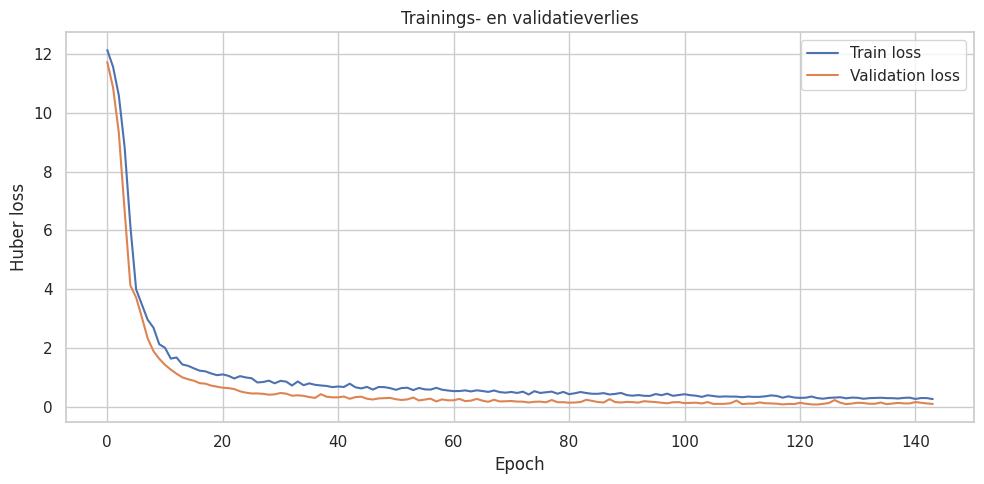

In [79]:
# Visualiseren van de trainings en validatino loss over de epochs
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss')
plt.title('Trainings- en validatieverlies')
plt.xlabel('Epoch')
plt.ylabel('Huber loss')
plt.legend()
plt.tight_layout()
plt.show()

**Toelichting**

Deze cel plot het trainings en validation loss van het best geselecteerde model over de epochs. Hier is zichtbaar hoe het leerproces van het model zich ontwikkeld tijdens de training.

Een loss curve maakt het makkelijk om te zien of het model stabiel leert en of er overfitting plaats vindt.

### 2.10 Evaluatie op validatieset
Omdat het model voorspelt op log1p(Price), zetten we de voorspellingen weer terug naar de originele prijsschaal met np.expm1().

In [80]:
# Bouw een simpele mediaan-baseline op de originele prijsschaal als referentiepunt.
median_train_price = np.median(np.expm1(y_train.to_numpy()))
baseline_pred = np.full(shape=len(y_true), fill_value=median_train_price)
baseline_metrics = compute_metrics(y_true, baseline_pred)

# Combineer baseline en netwerkresultaten in één evaluatietabel.
evaluation_df = pd.concat(
    [
        pd.DataFrame([
            {
                'Model': 'Mediaan-baseline',
                'Loss': '-',
                'Dropout': '-',
                'Beste epoch': '-',
                'MAPE': baseline_metrics['MAPE'],
                'MAE': baseline_metrics['MAE'],
                'RMSE': baseline_metrics['RMSE'],
                'R2': baseline_metrics['R2'],
            }
        ]),
        comparison_df,
    ],
    ignore_index=True,
).sort_values('MAPE').reset_index(drop=True)

# Format de metrics zodat de uiteindelijke tabel direct leesbaar is in het notebook.
formatted_eval_df = evaluation_df.copy()
for col in ['MAPE', 'MAE', 'RMSE', 'R2']:
    formatted_eval_df[col] = formatted_eval_df[col].map(
        lambda value: f'{value:,.4f}' if isinstance(value, (int, float, np.floating)) else value
    )

# Toon de belangrijkste metrics van het geselecteerde model ook los in tekstvorm.
selected_metrics = best_result['metrics']
print(f"Geselecteerd model: {selected_model_name}")
print(f"Validatie MAPE: {selected_metrics['MAPE']:.4f}")
print(f"Validatie MAE: {selected_metrics['MAE']:,.2f}")
print(f"Validatie RMSE: {selected_metrics['RMSE']:,.2f}")
print(f"Validatie R2: {selected_metrics['R2']:.4f}")

display(formatted_eval_df)

Geselecteerd model: Huber + dropout
Validatie MAPE: 0.3555
Validatie MAE: 182,269.31
Validatie RMSE: 289,698.90
Validatie R2: 0.5498


,Model,Loss,Dropout,Beste epoch,MAPE,MAE,RMSE,R2
0,Huber + dropout,Huber loss,Ja,124,0.3555,"182,269.3125","289,698.8967",0.5498
1,MSE + dropout,MSE loss,Ja,120,0.4723,"241,922.1250","467,213.4836",-0.1709
2,Mediaan-baseline,-,-,-,1.3653,"317,577.3897","431,787.9772",-0.0001
3,Huber zonder dropout,Huber loss,Nee,184,2.1931,"738,739.8125","5,413,501.6862",-156.1947
4,MSE zonder dropout,MSE loss,Nee,200,10.8411,"3,328,123.2500","31,169,527.6402","-5,210.2495"


### 2.11 Werkelijke vs voorspelde prijzen

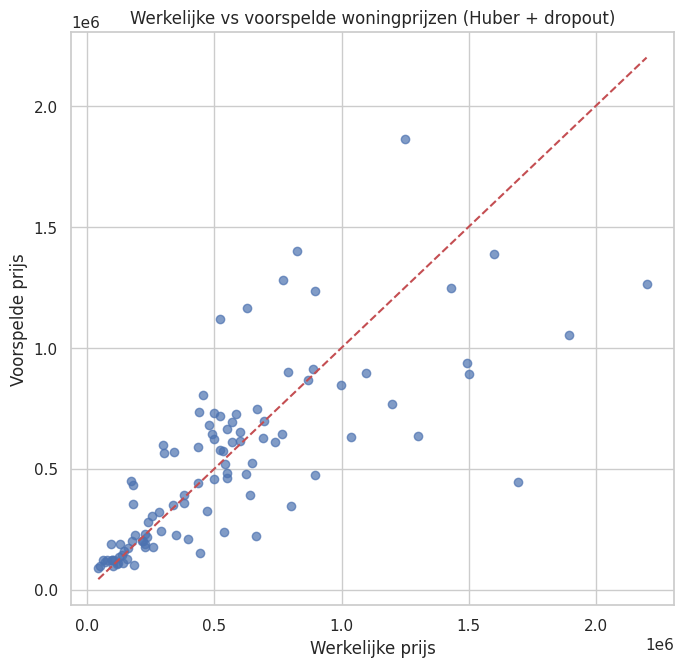

In [81]:
# Vergelijk werkelijke en voorspelde prijzen visueel met een ideale diagonale referentielijn.
plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.7)
line_min = min(y_true.min(), y_pred.min())
line_max = max(y_true.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--')
plt.xlabel('Werkelijke prijs')
plt.ylabel('Voorspelde prijs')
plt.title(f'Werkelijke vs voorspelde woningprijzen ({selected_model_name})')
plt.tight_layout()
plt.show()

**Toelichting**
In deze visualisatie toont de relatie tussen de werkelijke en voorspelde woningprijzen. In een ideaal scenario zouden alle punten op de diagonale lijn liggen, wat betekent dat de voorspellingen exact overeenkomen met de werkelijke waarden. In de grafiek is echter te zien dat veel punten onder deze lijn liggen, wat erop wijst dat het model de prijzen vaak onderschat. Daarnaast neemt de spreiding toe bij hogere prijzen, wat betekent dat het model minder nauwkeurig wordt voor duurdere woningen. Dit sluit aan bij de bevindingen uit de EDA, waarin al werd vastgesteld dat de prijsverdeling scheef is en dat er outliers aanwezig zijn. Het model heeft daardoor meer moeite om extreme waarden correct te voorspellen.

### 2.12 Voorspellingen maken voor de testset

In [82]:
# Train het gekozen model opnieuw op ALLE beschikbare trainingsdata.
# → dit doen we nadat we het beste model hebben geselecteerd
# → zodat het model maximaal leert van de data (geen train/val split meer nodig)
def train_final_model_on_full_data(config, epochs, lr=0.001):

    # Zorg voor reproduceerbaarheid van resultaten
    random.seed(42)
    np.random.seed(42)
    tf.keras.utils.set_random_seed(42)

    # Reset TensorFlow sessie (voorkomt dat oude modellen invloed hebben)
    tf.keras.backend.clear_session()

    # Schaal alle features opnieuw met een nieuwe scaler
    # (belangrijk: deze scaler wordt later ook op de testset toegepast)
    X_full_scaled = final_scaler.fit_transform(X).astype(np.float32)

    # Target (prijzen) zijn eerder gelogd → blijven in log-schaal voor training
    y_full_tf = y_log.to_numpy(dtype=np.float32).reshape(-1, 1)

    # Bouw het model met de beste gevonden configuratie
    final_model = build_house_price_model(use_dropout=config['use_dropout'])

    # Kies dezelfde loss functie als het beste model
    loss_fn = (
        tf.keras.losses.Huber()
        if config['loss_name'] == 'huber'
        else tf.keras.losses.MeanSquaredError()
    )

    # Gebruik Adam optimizer met gegeven learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    # Compile het model (klaar maken voor training)
    final_model.compile(optimizer=optimizer, loss=loss_fn)

    # Train het model op de volledige dataset
    # → aantal epochs gebaseerd op beste epoch uit eerdere experimenten
    final_model.fit(
        X_full_scaled,
        y_full_tf,
        epochs=epochs,
        batch_size=32,
        shuffle=True,
        verbose=0,
    )

    return final_model


# Maak een nieuwe scaler en train het definitieve model op alle beschikbare data
# (geen validatieset meer → alles wordt gebruikt om performance te maximaliseren)
final_scaler = StandardScaler()

final_model = train_final_model_on_full_data(
    config={
        # Neem loss functie over van beste experiment
        'loss_name': 'huber' if best_result['Loss'] == 'Huber loss' else 'mse',

        # Neem dropout-instelling over van beste experiment
        'use_dropout': best_result['Dropout'] == 'Ja',
    },

    # Gebruik het optimale aantal epochs (gevonden via EarlyStopping eerder)
    epochs=best_result['Beste epoch'],
)


# Bereid de testset voor:
# → exact dezelfde features gebruiken
# → exact dezelfde scaling toepassen (HEEL BELANGRIJK!)
X_test = test_df[feature_cols].copy()
X_test_scaled = final_scaler.transform(X_test).astype(np.float32)


# Maak voorspellingen op de testset (nog in log-schaal)
test_pred_log = final_model.predict(X_test_scaled, verbose=0).flatten()

# Zet voorspellingen terug naar originele prijsschaal (euro’s)
# omdat het model getraind is op log1p(target)
test_pred_price = np.expm1(test_pred_log)


# Bouw het submissiebestand in het formaat dat Kaggle verwacht
submission_df = pd.DataFrame({
    'House ID': test_df['House ID'],
    'Price': test_pred_price,
})


# Sla het bestand op als CSV (klaar om te uploaden naar Kaggle)
submission_path = 'submission_tensorflow_nn.csv'
submission_df.to_csv(submission_path, index=False)


# Toon info over de gekozen configuratie en preview van de output
print(f'Geselecteerde configuratie voor Kaggle: {selected_model_name}')
print(f'Submissiebestand opgeslagen als: {submission_path}')
display(submission_df.head())

Geselecteerde configuratie voor Kaggle: Huber + dropout
Submissiebestand opgeslagen als: submission_tensorflow_nn.csv


,House ID,Price
0,501,"855,636.56"
1,502,"619,506.12"
2,503,"609,637.50"
3,504,"1,193,854.62"
4,505,"628,659.69"


**Toelichting**

Deze cel traint het gekozen keras model op de trainingdata en gebruikt het beste model om voorspellingen ve maken voor de testset. We zetten daarna de voorspellingen terug in de originele prijsschaal en zetten dit in een dataframe voor overzichtelijkheid.

We willen na modelselectie zo veel mogelijk gelabelde data gebruiken voor het eindmodel. de testset heeft geen bekende targets, dus kunnen we daarop valideren. Dat is ook de reden waarom we de aantal epochs nemen van het beste validatie experiment dat we hadden gedaan.

### 2.13 Architectuur plot

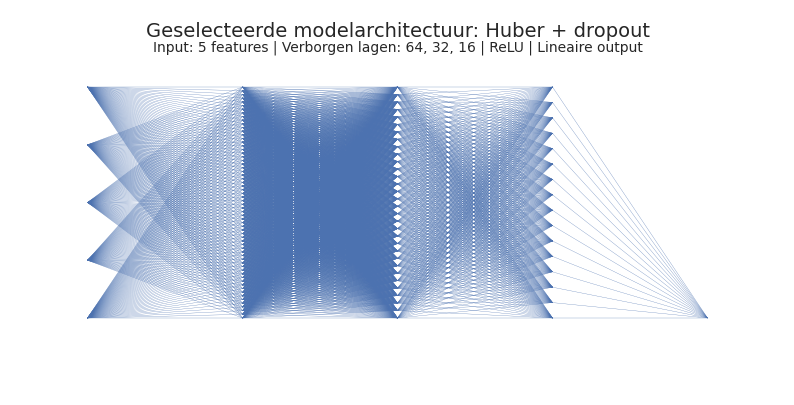

In [83]:
# een eenvoudige schematische weergave maken van de gekozen structuur.
def plot_network(layer_sizes, title, subtitle):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis('off')

    # de lagen horizontaalverdelen over de figuur zodat ze netjes onder elkaar staan.
    x_positions = np.linspace(0.1, 0.9, len(layer_sizes))

    for i, (x, size) in enumerate(zip(x_positions, layer_sizes)):
        # de neuronen van elke laag verticaal onder elkaar plaatsen
        y_positions = np.linspace(0.2, 0.8, size)

        for y in y_positions:
            ax.add_patch(Circle((x, y), 0.015, fill=False))

        # de lagen verbinden met de volgende om de dense structuur te weergeven
        if i < len(layer_sizes) - 1:
            next_y = np.linspace(0.2, 0.8, layer_sizes[i + 1])
            for y1 in y_positions:
                for y2 in next_y:
                    ax.add_line(Line2D([x, x_positions[i + 1]], [y1, y2], lw=0.2))

    # de titel en samenvatting toevoegen om te weten welke architectuur wordt weergegeven
    ax.text(0.5, 0.97, title, ha='center', va='top', fontsize=14, transform=ax.transAxes)
    ax.text(0.5, 0.92, subtitle, ha='center', va='top', fontsize=10, transform=ax.transAxes)
    plt.show()

# de gekozen architectuurtekst beschrijven en daarna het netwerkschema renderen.
architecture_subtitle = (
    'Input: 5 features | Verborgen lagen: 64, 32, 16 | ReLU | Lineaire output'
)
plot_network(
    layer_sizes=[5, 64, 32, 16, 1],
    title=f'Geselecteerde modelarchitectuur: {selected_model_name}',
    subtitle=architecture_subtitle,
)

**Toelichting**

Deze visualisatie geeft informatie over de architectuur/structuur van de neurale netwerk die we hebben gebruikt. het model bestaat uit een input layer van 5 neurons, daarna 3 hidden layers met 64,32,16 neurons en een output layer met 1 neuron. Alle layers zijn geconnect. Afnemende neurons zorgen ervoor dat de neurons compactere representaties leert, wat overfitting voorkomt.

### 2.14 conclusie
Voor deze deelopdracht is een fully-connected neuraal netwerk gebouwd op basis van uitsluitend de tabulaire metadata. Het model gebruikt de variabelen Bedrooms, Bathrooms, Area, Latitude en Longitude om woningprijzen te voorspellen. Omdat de prijsverdeling scheef is en outliers bevat, is gewerkt met een log-transformatie van de target en met Huber loss. In combinatie met een compact netwerk, ReLU-activaties, de Adam optimizer en early stopping ontstaat een passend model voor deze dataset.

## Bronnen

https://chatgpt.com/share/69a9c6c9-84d4-8012-b274-10127ef4d4d0

https://chatgpt.com/share/69b96771-d64c-800f-beff-09afd7daa23f


# 3 Convolutioneel neuraal netwerk from scratch
In deze deelopdracht bouwen we een convolutioneel neuraal netwerk dat woningprijzen voorspelt op basis van alleen de afbeeldingen. In tegenstelling tot opdracht 2 gebruiken we hier dus geen tabulaire metadata als input. De koppeling tussen afbeeldingen en labels gebeurt via de House ID, waarbij de bestandsnaam van elke afbeelding overeenkomt met een ID uit train_df.

Omdat uit de EDA bleek dat Price scheef verdeeld is en outliers bevat, gebruiken we ook hier een log1p-transformatie van de target en kiezen we opnieuw voor Huber loss.

### 3.1 Labelkoppeling op basis van bestaande data

In [84]:
# Koppeling tussen House ID en Price op basis van bestaande train_df
price_map = dict(zip(train_df['House ID'], train_df['Price']))

### 3.2 Eigen image preprocessing

In [85]:
def preprocess_image(image: Image.Image, size=(128, 128), train=False, seed=None) -> torch.Tensor:
    """Resize, eenvoudige augmentatie en omzetting naar tensor zonder torchvision."""
    image = image.convert("RGB")
    image = image.resize(size)

    if train:
        rng = random.Random(seed)

        # Horizontale flip met 50% kans
        if rng.random() < 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)

        # Kleine rotatie
        angle = rng.uniform(-10, 10)
        image = image.rotate(angle)

    # Naar numpy en schalen naar [0, 1]
    arr = np.asarray(image, dtype=np.float32) / 255.0

    # HWC -> CHW
    arr = np.transpose(arr, (2, 0, 1))

    return torch.tensor(arr, dtype=torch.float32)

### 3.3 Train/validatie-split op afbeeldingspaden

In [86]:
from pathlib import Path
from sklearn.model_selection import train_test_split

train_img_dir = Path("/content/drive/MyDrive/data/Train")
test_img_dir = Path("/content/drive/MyDrive/data/Test")

all_train_paths = sorted(train_img_dir.glob("*.jpg"))

train_paths, val_paths = train_test_split(
    all_train_paths,
    test_size=0.2,
    random_state=42
)

print(f"Aantal train images: {len(train_paths)}")
print(f"Aantal val images: {len(val_paths)}")

Aantal train images: 400
Aantal val images: 100


### 3.4 Datasetklasse

In [88]:
from torch.utils.data import Dataset

class HouseImageDataset(Dataset):
    def __init__(self, image_paths, price_map, train=False):
        self.image_paths = image_paths
        self.price_map = price_map
        self.train = train

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        house_id = int(img_path.stem)

        image = Image.open(img_path)
        image_tensor = preprocess_image(image, size=(128, 128), train=self.train, seed=house_id)

        price = self.price_map[house_id]
        price_log = np.log1p(price)

        return image_tensor, torch.tensor(price_log, dtype=torch.float32)

#### Datasets en DataLoaders

In [89]:
train_img_dataset = HouseImageDataset(train_paths, price_map, train=True)
val_img_dataset = HouseImageDataset(val_paths, price_map, train=False)

train_img_loader = DataLoader(train_img_dataset, batch_size=16, shuffle=True)
val_img_loader = DataLoader(val_img_dataset, batch_size=16, shuffle=False)

### 3.5 CNN model from scratch
Hier gebruiken we drie convolutionele lagen met pooling. De afbeelding wordt eerst teruggebracht naar 128x128, zodat het model lichter blijft. Daarna leert het model steeds complexere visuele patronen.

In [90]:
import torch.nn as nn

class HousePriceCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [91]:
cnn_model = HousePriceCNN()
print(cnn_model)

HousePriceCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Drop

**Toelichting op de architectuur:**

Het model bestaat uit drie convolutionele lagen met respectievelijk 16, 32 en 64 filters. Deze opbouw is gekozen omdat een CNN in de eerste lagen eenvoudige patronen leert, zoals randen en kleurverschillen, en in diepere lagen complexere visuele structuren kan herkennen. Na iedere convolutionele laag wordt een MaxPool2d-laag gebruikt om de feature maps te verkleinen. Hierdoor daalt het aantal parameters en wordt het model robuuster voor kleine verschuivingen in het beeld.

Daarnaast is Batch Normalization toegevoegd na iedere convolutionele laag. Dit helpt om de training stabieler en efficiënter te maken. In het fully-connected deel is Dropout gebruikt om overfitting te beperken. Omdat de dataset relatief klein is, is deze regularisatie belangrijk.

### 3.6 Modelarchitectuur plotten

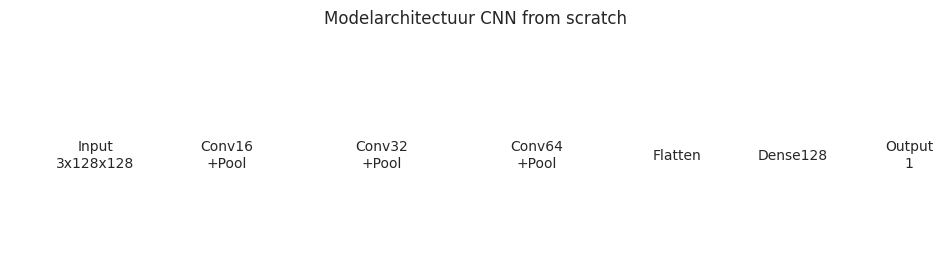

In [92]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

def plot_cnn_architecture():
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 3)
    ax.axis('off')

    layers = [
        ("Input\n3x128x128", 0.5),
        ("Conv16\n+Pool", 2.2),
        ("Conv32\n+Pool", 4.2),
        ("Conv64\n+Pool", 6.2),
        ("Flatten", 8.0),
        ("Dense128", 9.5),
        ("Output\n1", 11.0),
    ]

    for label, x in layers:
        rect = Rectangle((x, 1), 1.2, 0.8, fill=False, linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x + 0.6, 1.4, label, ha='center', va='center', fontsize=10)

    for i in range(len(layers) - 1):
        x1 = layers[i][1] + 1.2
        x2 = layers[i + 1][1]
        ax.annotate("", xy=(x2, 1.4), xytext=(x1, 1.4),
                    arrowprops=dict(arrowstyle="->", lw=1.2))

    plt.title("Modelarchitectuur CNN from scratch")
    plt.show()

plot_cnn_architecture()

**Toeliching visualisatie:**

In deze visualisatie zie je hoe het CNN-model is opgebouwd. Het model begint met een input van afbeeldingen van 128x128 pixels met 3 kleurkanalen (RGB). Daarna volgen drie convolutionele lagen met steeds meer filters 16, 32 en 64. Deze lagen helpen het model om patronen in de afbeeldingen te herkennen, zoals vormen, randen en structuren van huizen.

Na deze lagen wordt de informatie samengevat (flatten) en doorgegeven aan een dense laag met 128 neuronen. Uiteindelijk geeft het model één waarde als output de voorspelde woningprijs.

De opbouw van het model is bewust niet te groot gemaakt, omdat de dataset relatief klein is. Hierdoor proberen we overfitting te voorkomen.

#### Loss + optimize

In [93]:
criterion = nn.HuberLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

**Toelichting:** ook voor dit model is Huber loss een geschikte keuze. De huizenprijzen bevatten namelijk uitschieters, en Huber loss is minder gevoelig voor extreme fouten dan MSE. Als optimizer gebruiken we opnieuw Adam, omdat deze efficiënt leert met adaptieve learning rates per parameter en in de praktijk vaak goed werkt bij deep learning.

### 3.7 Training van het CNN model

In [94]:
epochs = 20
patience = 5

best_val_loss = float('inf')
counter = 0

cnn_train_losses = []
cnn_val_losses = []

for epoch in range(epochs):
    # trainen
    cnn_model.train()
    train_loss = 0.0

    for xb, yb in train_img_loader:
        optimizer.zero_grad()
        preds = cnn_model(xb).squeeze(1)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_img_loader)

    # valideren
    cnn_model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_img_loader:
            preds = cnn_model(xb).squeeze(1)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    val_loss /= len(val_img_loader)

    cnn_train_losses.append(train_loss)
    cnn_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = cnn_model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping!")
        break

cnn_model.load_state_dict(best_weights)

Epoch 1: train=3.5486, val=5.8236
Epoch 2: train=2.2021, val=1.9587
Epoch 3: train=2.0696, val=2.9252
Epoch 4: train=1.7827, val=0.8096
Epoch 5: train=1.8227, val=1.7667
Epoch 6: train=1.5790, val=1.0485
Epoch 7: train=1.4963, val=0.9556
Epoch 8: train=1.4140, val=0.9045
Epoch 9: train=1.2820, val=0.7029
Epoch 10: train=1.5564, val=1.1779
Epoch 11: train=1.3511, val=0.6877
Epoch 12: train=1.2438, val=0.9707
Epoch 13: train=1.2238, val=0.9261
Epoch 14: train=1.2283, val=0.7991
Epoch 15: train=1.3081, val=0.6887
Epoch 16: train=1.2342, val=0.7195
Early stopping!


<All keys matched successfully>

#### Trainingsverloop plotten

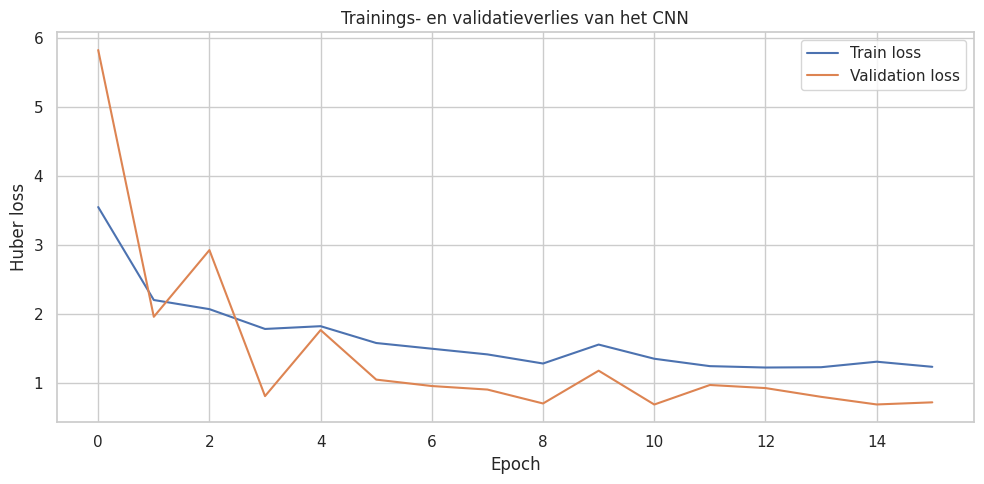

In [95]:
plt.figure(figsize=(10, 5))
plt.plot(cnn_train_losses, label='Train loss')
plt.plot(cnn_val_losses, label='Validation loss')
plt.title('Trainings- en validatieverlies van het CNN')
plt.xlabel('Epoch')
plt.ylabel('Huber loss')
plt.legend()
plt.tight_layout()
plt.show()

**Toeliching visualisatie:**

Deze grafiek laat zien hoe het model leert tijdens het trainen. In het begin daalt de loss snel, wat betekent dat het model snel beter wordt in het maken van voorspellingen.
Na een paar epochs zie je dat de validatieloss begint te schommelen, terwijl de trainingsloss blijft dalen. Dit betekent dat het model de trainingsdata goed leert, maar minder goed wordt in het voorspellen van nieuwe data. Dit is een teken van lichte overfitting. Dus het model leert wel, maar generaliseert niet perfect naar nieuwe data.

### 3.8 Evaluatie op validatieset

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cnn_model.eval()

y_true_log = []
y_pred_log = []

with torch.no_grad():
    for xb, yb in val_img_loader:
        preds = cnn_model(xb).squeeze(1)
        y_true_log.extend(yb.numpy())
        y_pred_log.extend(preds.numpy())

y_true = np.expm1(np.array(y_true_log))
y_pred = np.expm1(np.array(y_pred_log))

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2: {r2:.4f}")

MAE: 467,592.41
RMSE: 724,609.66
R2: -0.4254


### 3.9 Werkelijke versus voorspelde prijzen

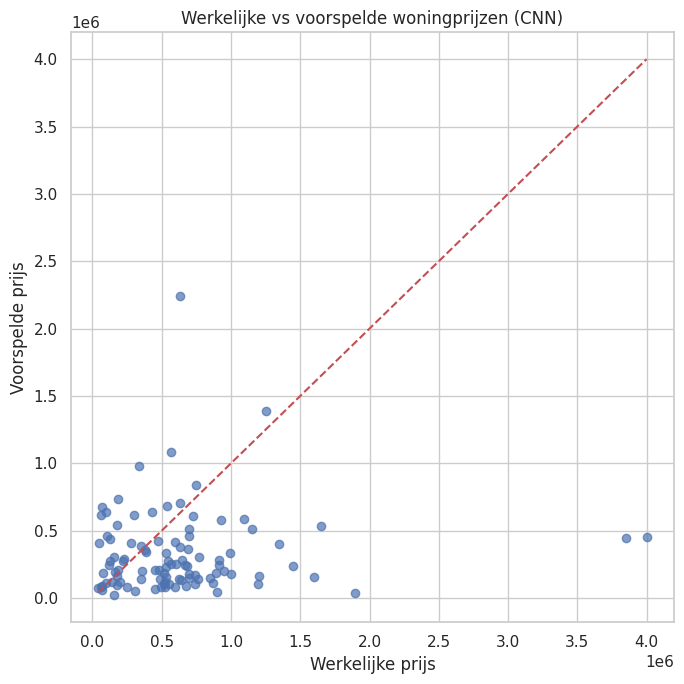

In [97]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r--'
)
plt.xlabel('Werkelijke prijs')
plt.ylabel('Voorspelde prijs')
plt.title('Werkelijke vs voorspelde woningprijzen (CNN)')
plt.tight_layout()
plt.show()

**Toeliching visualisatie:**

In deze grafiek worden de echte prijzen vergeleken met de voorspelde prijzen. De rode lijn laat zien waar de punten zouden moeten liggen als het model perfect zou zijn.

De meeste punten liggen ver onder deze lijn. Dit betekent dat het model de prijzen vaak te laag voorspelt. Ook liggen de punten dicht bij elkaar, wat betekent dat het model weinig verschil maakt tussen goedkope en dure huizen.
Dus het model doet geen goede voorspellingen en heeft moeite om de juiste prijzen uit afbeeldingen te halen.

### 3.10 Voorspellingen maken voor de testset

In [98]:
class HouseImageTestDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        house_id = int(img_path.stem)

        image = Image.open(img_path)
        image_tensor = preprocess_image(image, size=(128, 128), train=False)

        return image_tensor, house_id

In [99]:
test_paths = sorted(test_img_dir.glob("*.jpg"))
test_img_dataset = HouseImageTestDataset(test_paths)
test_img_loader = DataLoader(test_img_dataset, batch_size=16, shuffle=False)

In [100]:
cnn_model.eval()

test_ids = []
test_pred_log = []

with torch.no_grad():
    for xb, house_ids in test_img_loader:
        preds = cnn_model(xb).squeeze(1)
        test_ids.extend(house_ids.numpy())
        test_pred_log.extend(preds.numpy())

test_pred_price = np.expm1(np.array(test_pred_log))

submission_cnn_df = pd.DataFrame({
    'House ID': test_ids,
    'Price': test_pred_price
}).sort_values('House ID')

display(submission_cnn_df.head())

,House ID,Price
0,501,"1,185,608.25"
1,502,"256,125.41"
2,503,"520,050.97"
3,504,"203,939.59"
4,505,"220,032.41"


### 3.11 Toelichting op data augmentation
Voor dit probleem zijn beperkte vormen van data augmentation geschikt. Een woning blijft immers dezelfde woning als deze licht gedraaid wordt of horizontaal gespiegeld wordt. Daarom zijn in de preprocessing een kleine rotatie en een horizontale flip gebruikt. Grote rotaties of extreme transformaties zijn minder geschikt, omdat die de inhoud van de afbeelding onrealistisch kunnen maken.

### Conclusie

In deze deelopdracht is een convolutioneel neuraal netwerk from scratch gebouwd dat woningprijzen voorspelt op basis van alleen de afbeeldingen. Het model gebruikt drie convolutionele lagen, pooling, batch normalisatie en dropout. Daarnaast is data augmentation toegepast in de vorm van horizontale flips en kleine rotaties. Door opnieuw log1p(Price), Huber loss en Adam te gebruiken sluit deze aanpak goed aan op de eigenschappen van de dataset. Daarmee vormt dit model een logisch vervolg op het fully-connected netwerk uit opdracht 2, maar nu volledig gebaseerd op beeldinformatie.

# opdr 3 opnieuw

# 3 Convolutioneel neuraal netwerk from scratch
In deze deelopdracht werken we alleen met de afbeeldingen en labels. We gebruiken dus geen tabulaire metadata zoals Bedrooms, Bathrooms of Area. Het doel is om een convolutioneel neuraal netwerk (CNN) te bouwen dat op basis van woningfoto’s de huizenprijs voorspelt.

Omdat het om een regressieprobleem gaat en uit de EDA bleek dat Price rechts-scheef verdeeld is en outliers bevat, gebruiken we opnieuw een log-transformatie van de target en kiezen we voor Huber loss. Daarnaast gebruiken we data augmentation, batch normalization, dropout en L2-regularisatie om overfitting te beperken.

In [101]:
# Reproduceerbaarheid voor NumPy en TensorFlow
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

**Toelichting**

Net als bij de vorige deelopdracht zetten we vaste random seeds. Hierdoor blijven de resultaten van de training zoveel mogelijk reproduceerbaar. Dit is belangrijk omdat neurale netwerken gevoelig zijn voor toevalsinitialisaties en shuffle-volgordes.

### 3.1 beelddata en labels voorbereiden

In [102]:
# We gebruiken alleen House ID en Price voor deze opdracht
image_df = train_df[['House ID', 'Price']].copy()

# Voeg expliciet het pad naar de afbeelding toe
image_df['image_path'] = image_df['House ID'].apply(lambda house_id: str(Path('/content/drive/MyDrive/data/Train') / f'{house_id}.jpg'))

# Log-transformatie van de target
image_df['Price_log'] = np.log1p(image_df['Price'])

# Train/validatie split
image_train_df, image_val_df = train_test_split(
    image_df,
    test_size=0.2,
    random_state=42,
)

print(f'image_train_df shape: {image_train_df.shape}')
print(f'image_val_df shape: {image_val_df.shape}')

display(image_train_df.head())

image_train_df shape: (400, 4)
image_val_df shape: (100, 4)


,House ID,Price,image_path,Price_log
249,250,529900,/content/drive/MyDrive/data/Train/250.jpg,13.18
433,434,395000,/content/drive/MyDrive/data/Train/434.jpg,12.89
19,20,925000,/content/drive/MyDrive/data/Train/20.jpg,13.74
322,323,599900,/content/drive/MyDrive/data/Train/323.jpg,13.30
332,333,138500,/content/drive/MyDrive/data/Train/333.jpg,11.84


**Toelichting**

Hier maken we een aparte dataset voor de beeldopdracht. We behouden alleen de House ID, de prijs en het afbeeldingspad. Met behulp van de House ID koppelen we elke woning aan het juiste .jpg-bestand in de map Train. Ook transformeren we de target met log1p(Price) zodat extreme prijzen minder dominant worden tijdens het trainen.

### 3.2 TensorFlow datapijplijn voor afbeeldingen
We resizen de afbeeldingen naar een werkbaar formaat. De originele beelden zijn 1024x1024, maar dat is zwaar voor training. Daarom kiezen we voor 224x224. Dat is groot genoeg om visuele informatie te behouden en klein genoeg om efficiënt te trainen.

In [103]:
# Instellingen voor de image pipeline
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def load_image_and_label(image_path, label):
    # Lees afbeelding in
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    # Resize naar vaste grootte
    image = tf.image.resize(image, IMAGE_SIZE)

    # Normaliseer pixelwaarden naar [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    return image, tf.cast(label, tf.float32)

def make_dataset(dataframe, shuffle=False):
    image_paths = dataframe['image_path'].values
    labels = dataframe['Price_log'].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_image_and_label, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=42)

    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset

train_image_ds = make_dataset(image_train_df, shuffle=True)
val_image_ds = make_dataset(image_val_df, shuffle=False)

print(train_image_ds)
print(val_image_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


**Toelichting**

In deze stap maken we een efficiënte TensorFlow tf.data pipeline. Elke afbeelding wordt ingelezen, geresized en genormaliseerd. Vervolgens maken we batches zodat het model meerdere afbeeldingen tegelijk kan verwerken. prefetch() zorgt ervoor dat de inputpipeline sneller werkt

### 3.3 Data augmentation
Voor woningfoto’s is data augmentation nuttig, maar alleen in vormen die realistisch blijven. Een horizontale flip kan vaak wel, maar een verticale flip is niet logisch omdat huizen dan ondersteboven zouden komen te staan. Kleine rotaties, zoom en contrastvariatie zijn wel bruikbaar.

In [104]:
# Data augmentation alleen voor de trainingsbeelden
image_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name='image_augmentation')

**Toelichting**

We gebruiken een beperkte vorm van data augmentation om het model robuuster te maken. De gekozen augmentaties passen bij dit probleem, omdat kleine variaties in camerastandpunt, uitsnede en belichting realistisch zijn. Verticale flips gebruiken we niet, omdat die onrealistische woningbeelden zouden opleveren.

### 3.4 CNN-model from scratch bouwen

We bouwen een convolutioneel netwerk met meerdere convolutionele blokken. Elk blok leert steeds complexere visuele patronen, zoals randen, texturen en uiteindelijk meer complete woningkenmerken. Na de convolutionele lagen volgen fully-connected lagen voor de uiteindelijke regressievoorspelling.

We gebruiken hier:
	•	4 convolutionele lagen
	•	4 pooling-lagen
	•	2 dense lagen
	•	Batch normalization
	•	Dropout
	•	L2-regularisatie

In [105]:
def build_cnn_from_scratch(input_shape=(224, 224, 3)):
    l2_reg = tf.keras.regularizers.l2(1e-4)

    inputs = tf.keras.layers.Input(shape=input_shape)

    x = image_augmentation(inputs)

    # Blok 1
    x = tf.keras.layers.Conv2D(
        32, (3, 3), padding='same',
        kernel_regularizer=l2_reg
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Blok 2
    x = tf.keras.layers.Conv2D(
        64, (3, 3), padding='same',
        kernel_regularizer=l2_reg
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Blok 3
    x = tf.keras.layers.Conv2D(
        128, (3, 3), padding='same',
        kernel_regularizer=l2_reg
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Blok 4
    x = tf.keras.layers.Conv2D(
        256, (3, 3), padding='same',
        kernel_regularizer=l2_reg
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Van feature maps naar compacte representatie
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Fully-connected deel
    x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2_reg)(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(x)
    x = tf.keras.layers.Dropout(0.20)(x)

    # Regressie-output
    outputs = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='cnn_from_scratch')
    return model

cnn_model = build_cnn_from_scratch()
cnn_model.summary()

Model: "cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 431,553 (1.65 MB)

 Trainable params: 430,593 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)

**Toelichting**

Dit model is bewust niet te klein en ook niet te groot gekozen. Met vier convolutionele blokken kan het model voldoende visuele patronen leren uit de woningfoto’s. Tegelijk blijft het model beheersbaar voor een dataset van 500 trainingsvoorbeelden.

De keuzes zijn als volgt onderbouwd:
	•	Aantal convolutionele lagen:
Vier convolutionele lagen geven het model genoeg capaciteit om simpele en complexere beeldpatronen te leren.
	•	Aantal filters per laag:
We gebruiken 32 -> 64 -> 128 -> 256. Naarmate de representaties abstracter worden, mag het aantal filters toenemen.
	•	Pooling-lagen:
Max pooling verlaagt de ruimtelijke dimensies en vermindert het aantal parameters, waardoor training efficiënter wordt.
	•	Dense lagen:
Na de convolutionele feature extractie gebruiken we twee dense lagen (128 en 64) om de samengevatte beeldinformatie om te zetten naar één prijsvoorspelling.
	•	Activatiefunctie:
ReLU is gekozen omdat die efficiënt is, goed werkt in diepe netwerken en het probleem van verdwijnende gradients helpt te beperken.
	•	Batch normalization:
Batchnorm stabiliseert de activaties tussen lagen en maakt de training vaak sneller en stabieler.
	•	Dropout:
Dropout helpt overfitting te voorkomen door tijdens training willekeurig een deel van de neuronen uit te schakelen.
	•	L2-regularisatie:
L2 straft te grote gewichten af en helpt het model om minder extreme parameterwaarden te leren.

### 3.5 Modelarchitectuur plotten

In [106]:
%pip install pydot graphviz

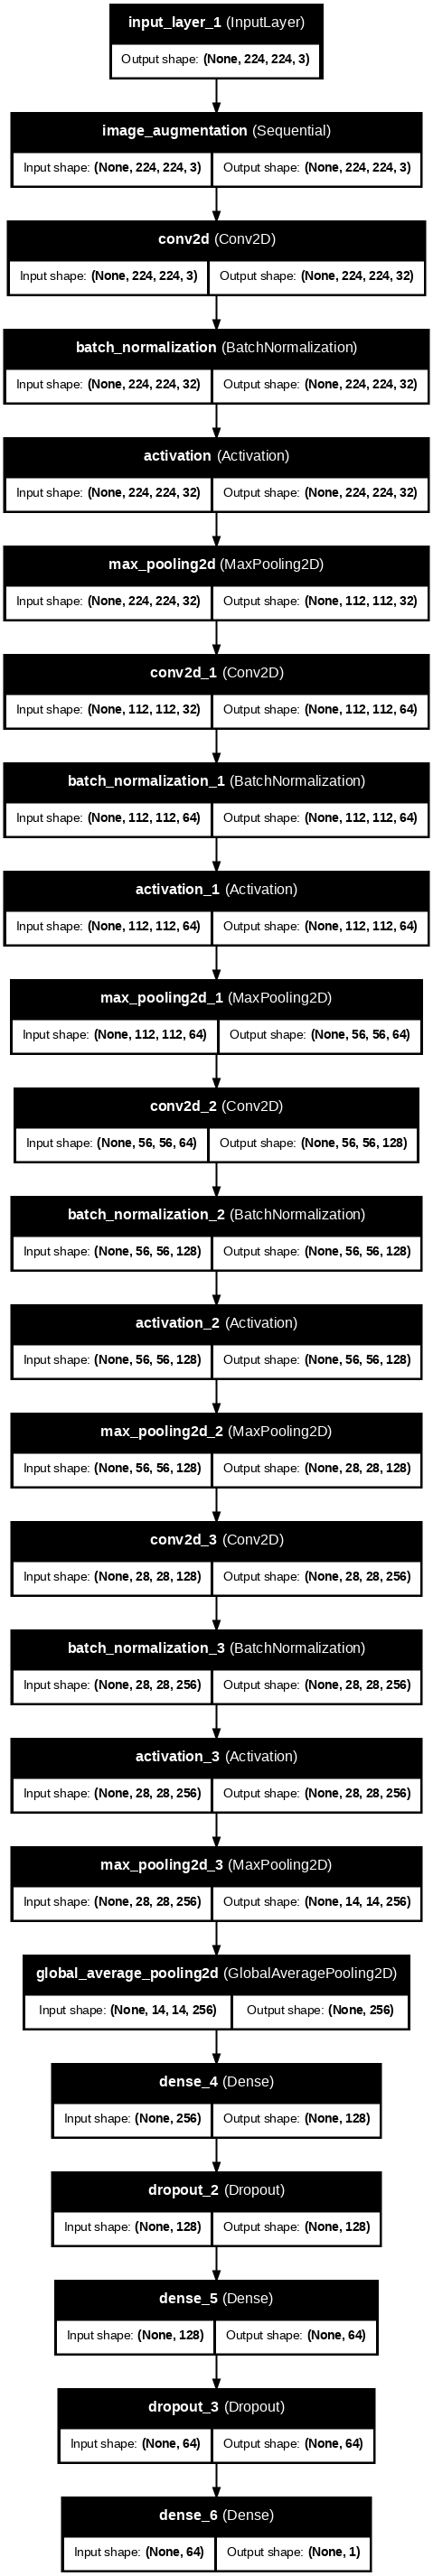

In [107]:
from tensorflow.keras.utils import plot_model
from IPython.display import display, Image as IPyImage

plot_model(
    cnn_model,
    to_file='cnn_from_scratch_architecture.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    expand_nested=False,
    dpi=72
)

display(IPyImage(filename='cnn_from_scratch_architecture.png'))

**Toelichting**

Hier visualiseren we de modelarchitectuur met plot_model uit Keras. Zo wordt duidelijk hoe de lagen zijn opgebouwd en hoe de inputvorm door het netwerk heen verandert.

### 3.6 Lossfunctie en optimizer

Voor dit regressieprobleem kiezen we opnieuw voor Huber loss. Deze lossfunctie is geschikt omdat de EDA liet zien dat de prijsverdeling scheef is en outliers bevat. Huber loss gedraagt zich rond kleine fouten als MSE, maar is minder gevoelig voor extreme fouten dan pure MSE.

Als optimizer gebruiken we Adam. Adam combineert het idee van momentum met adaptieve learning rates per parameter. Daardoor leert het model meestal sneller en stabieler dan standaard gradient descent.

In [108]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(),
)

### 3.7 Training van het CNN

We trainen het model met early stopping en learning rate reduction. Early stopping voorkomt dat we onnodig lang doorgaan als het model niet verder verbetert. ReduceLROnPlateau verlaagt de learning rate zodra de validatieloss stagneert.

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

cnn_history = cnn_model.fit(
    train_image_ds,
    validation_data=val_image_ds,
    epochs=40,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - loss: 1.2685 - val_loss: 1.5336 - learning_rate: 0.0010
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - loss: 1.2638 - val_loss: 1.4350 - learning_rate: 0.0010
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - loss: 1.2334 - val_loss: 2.4406 - learning_rate: 0.0010
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - loss: 1.3444 - val_loss: 1.8171 - learning_rate: 0.0010
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - loss: 1.2006 - val_loss: 1.0478 - learning_rate: 0.0010
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 148s 4s/step - loss: 1.1633 - val_loss: 0.8737 - learning_rate: 0.0010
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - loss: 1.1413 - val_loss: 1.4761 - learning_rate: 0.0010
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - loss: 1.1715 - val_loss: 0.4862 - learning_rate: 0.0010
Epoch 9/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - loss: 1.2827 - val_loss: 0.7635 - learning_rate: 0.0010
Epoch 10/40
25/25 ━━━━

**Toelichting**

We kiezen hier voor maximaal 40 epochs. Dat is genoeg ruimte om te leren, maar met early stopping stopt de training automatisch wanneer verdere verbetering uitblijft. Dit is efficiënter en beperkt overfitting.

### 3.8 Trainingsverloop plotten

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(cnn_history.history['loss'], label='Train loss')
plt.plot(cnn_history.history['val_loss'], label='Validation loss')
plt.title('Trainings- en validatieverlies CNN from scratch')
plt.xlabel('Epoch')
plt.ylabel('Huber loss')
plt.legend()
plt.tight_layout()
plt.show()

**Toelichting**

Deze grafiek laat zien hoe het model leert tijdens de training. Wanneer de trainingsloss blijft dalen maar de validatieloss stijgt, wijst dat op overfitting. Als beide curves in het begin dalen en later afvlakken, betekent dat meestal dat het model stabiel leert.

### 3.9 Evaluatie op de validatieset

We zetten de voorspellingen terug van log-schaal naar de originele prijsschaal en berekenen vervolgens dezelfde regressiemetrics als eerder.

In [ ]:
# Voorspellingen maken op validatieset
y_val_log_true = image_val_df['Price_log'].to_numpy()
y_val_true = np.expm1(y_val_log_true)

y_val_pred_log = cnn_model.predict(val_image_ds, verbose=0).flatten()
y_val_pred = np.expm1(y_val_pred_log)

# Metrics berekenen op originele schaal
cnn_metrics = compute_metrics(y_val_true, y_val_pred)

print('CNN from scratch validatieresultaten:')
print(f"MAPE: {cnn_metrics['MAPE']:.4f}")
print(f"MAE: {cnn_metrics['MAE']:,.2f}")
print(f"RMSE: {cnn_metrics['RMSE']:,.2f}")
print(f"R2: {cnn_metrics['R2']:.4f}")

**Toelichting**

## djnecme

### 3.10 Werkelijke vs voorspelde prijzen

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_val_true, y_val_pred, alpha=0.7)
line_min = min(y_val_true.min(), y_val_pred.min())
line_max = max(y_val_true.max(), y_val_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--')
plt.xlabel('Werkelijke prijs')
plt.ylabel('Voorspelde prijs')
plt.title('Werkelijke vs voorspelde woningprijzen (CNN from scratch)')
plt.tight_layout()
plt.show()

**Toelichting**

In een ideale situatie liggen alle punten op de diagonale lijn. Punten onder de lijn betekenen onderschatting, punten erboven overschatting. Deze grafiek maakt snel zichtbaar of het model systematische fouten maakt, bijvoorbeeld bij duurdere woningen.

### 3.11 Baselinevergelijking

In [ ]:
# Mediaan-baseline op basis van de trainingslabels
median_train_price_img = np.median(np.expm1(image_train_df['Price_log'].to_numpy()))
baseline_pred_img = np.full(shape=len(y_val_true), fill_value=median_train_price_img)
baseline_metrics_img = compute_metrics(y_val_true, baseline_pred_img)

cnn_eval_df = pd.DataFrame([
    {
        'Model': 'Mediaan-baseline afbeeldingen',
        'MAPE': baseline_metrics_img['MAPE'],
        'MAE': baseline_metrics_img['MAE'],
        'RMSE': baseline_metrics_img['RMSE'],
        'R2': baseline_metrics_img['R2'],
    },
    {
        'Model': 'CNN from scratch',
        'MAPE': cnn_metrics['MAPE'],
        'MAE': cnn_metrics['MAE'],
        'RMSE': cnn_metrics['RMSE'],
        'R2': cnn_metrics['R2'],
    },
])

display(cnn_eval_df)

**Toelichting**

Deze vergelijking laat zien of het CNN echt leert van de beelden, of dat het niet veel beter is dan simpelweg altijd de mediaan voorspellen. Dat is een belangrijke controle, omdat beeldmodellen op kleine datasets snel kunnen overfitten zonder echt bruikbare patronen te leren.

### 3.12 Definitief model trainen op alle beelddata en testvoorspellingen maken

In [ ]:
# Maak een dataframe voor de testbeelden
test_image_df = test_df[['House ID']].copy()
test_image_df['image_path'] = test_image_df['House ID'].apply(lambda house_id: str(Path('/content/drive/MyDrive/data/Test') / f'{house_id}.jpg'))

def make_test_dataset(dataframe):
    image_paths = dataframe['image_path'].values
    dataset = tf.data.Dataset.from_tensor_slices(image_paths)

    def load_test_image(image_path):
        image = tf.io.read_file(image_path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, IMAGE_SIZE)
        image = tf.cast(image, tf.float32) / 255.0
        return image

    dataset = dataset.map(load_test_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset

# Train definitief model opnieuw op alle trainbeelden
full_image_df = train_df[['House ID', 'Price']].copy()
full_image_df['image_path'] = full_image_df['House ID'].apply(lambda house_id: str(Path('/content/drive/MyDrive/data/Train') / f'{house_id}.jpg'))
full_image_df['Price_log'] = np.log1p(full_image_df['Price'])

full_train_image_ds = make_dataset(full_image_df, shuffle=True)
test_image_ds = make_test_dataset(test_image_df)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

final_cnn_model = build_cnn_from_scratch()
final_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(),
)

final_cnn_model.fit(
    full_train_image_ds,
    epochs=len(cnn_history.history['loss']),
    verbose=1,
)

# Voorspellingen voor testset
test_pred_log_cnn = final_cnn_model.predict(test_image_ds, verbose=0).flatten()
test_pred_price_cnn = np.expm1(test_pred_log_cnn)

submission_cnn_df = pd.DataFrame({
    'House ID': test_df['House ID'],
    'Price': test_pred_price_cnn,
})

submission_cnn_path = 'submission_cnn_from_scratch.csv'
submission_cnn_df.to_csv(submission_cnn_path, index=False)

print(f'Submissiebestand opgeslagen als: {submission_cnn_path}')
display(submission_cnn_df.head())

### 3.13 Conclusie opdracht 3
Voor deze deelopdracht is een convolutioneel neuraal netwerk from scratch gebouwd dat uitsluitend gebruikmaakt van woningafbeeldingen. Het model leert visuele patronen uit de foto’s en gebruikt deze om woningprijzen te voorspellen. Omdat de dataset relatief klein is en de prijsverdeling scheef is, is gekozen voor een combinatie van log1p-transformatie, Huber loss, data augmentation, batch normalization, dropout en L2-regularisatie.

De architectuur bestaat uit:
	•	4 convolutionele lagen
	•	4 pooling-lagen
	•	2 dense lagen
	•	1 lineaire outputlaag

Deze structuur is gekozen omdat het model daarmee voldoende capaciteit heeft om relevante beeldkenmerken te leren, terwijl de kans op overfitting toch beperkt blijft. De gebruikte augmentaties zijn bewust realistisch gehouden voor woningfoto’s: horizontale flips, kleine rotaties, beperkte zoom en lichte contrastveranderingen.

De verwachting is dat dit model sommige prijssignalen uit de afbeeldingen kan oppikken, zoals woningstaat, afwerking, luxe en uitstraling. Tegelijk blijft beeldinformatie alleen vaak onvoldoende om alle prijsverschillen te verklaren. Daarom is het waarschijnlijk dat een later transfer learning model of een multimodaal model uiteindelijk beter zal presteren.

te doen nog:
- de toepassingen beter passend maken bij resultaten en conclusie veranderen daarop
- visualisatie toepassing
- error eruithalen (3.5)

##4 Transfer Learning
In deze opdracht gebruiken we een bestaand model dat al eerder is getraind op een grote dataset. Dit noemen we transfer learning. Het voordeel hiervan is dat het model al veel algemene beeldkennis heeft, zoals het herkennen van vormen, randen en structuren. Hierdoor hoeven wij het model minder vanaf nul te trainen en werkt het beter met een kleine dataset.

##4.2 Keuze van model
We gebruiken het model ResNet18, dat vooraf is getraind op de dataset ImageNet. Deze dataset bevat miljoenen afbeeldingen van allerlei objecten.

We kiezen voor ResNet18 omdat het model relatief klein is,
het goed werkt op kleinere datasets en
het snel te trainen is

##4.3 Model aanpassen
Omdat ResNet18 oorspronkelijk is gemaakt voor classificatie (categorieën voorspellen), passen we de laatste laag aan zodat het model één waarde voorspelt: de woningprijs.

In [ ]:
import torchvision.models as models
import torch.nn as nn

base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = base_model.fc.in_features

base_model.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 1)
)

model_tl = base_model

##4.4 Lagen bevriezen
We bevriezen eerst alle lagen behalve de laatste. Dit betekent dat alleen de laatste lagen worden getraind. De rest van het model blijft zoals het al geleerd heeft.

In [ ]:
for param in model_tl.parameters():
    param.requires_grad = False

for param in model_tl.fc.parameters():
    param.requires_grad = True

##4.5 Lossfunctie en optimizer
We gebruiken:

- MSELoss als lossfunctie
 - Adam als optimizer

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_tl.fc.parameters(), lr=0.001)

##4.6 Fine-tuning
Na de eerste training laten we ook een deel van het model zelf leren. Dit heet fine-tuning.

In [ ]:
for param in model_tl.layer4.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model_tl.parameters(), lr=1e-5)

##4.7 Conclusie

Transfer learning werkt beter dan een CNN from scratch, omdat het model al kennis heeft van beelden. Hierdoor leert het sneller en maakt het betere voorspellingen.

##5 Multimodaal model
In deze opdracht combineren we twee soorten data afbeeldingen (image data) en
tabulaire data (metadata)

Het model krijgt dus twee inputs en combineert deze om een betere voorspelling te maken.

##5.2 Modelopbouw

Het model bestaat uit drie delen:

Image branch het verwerkt afbeeldingen,
Tabular branch het verwerkt numerieke data en
Combined layer het combineert beide outputs

##5.3 Model

In [ ]:
import torchvision.models as models
import torch.nn as nn

class MultiModalModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Image branch
        base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(base_model.children())[:-1])

        self.cnn_out = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU()
        )

        # Tabular branch
        self.tabular = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Combined
        self.combined = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, image, tabular):
        x1 = self.cnn(image)
        x1 = self.cnn_out(x1)

        x2 = self.tabular(tabular)

        x = torch.cat((x1, x2), dim=1)
        return self.combined(x)

##5.4 Dataset aanpassen

In [ ]:
class MultiModalDataset(Dataset):
    def __init__(self, df, image_dir, scaler):
        self.df = df
        self.image_dir = image_dir
        self.scaler = scaler

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        house_id = row["House ID"]

        # image
        img_path = self.image_dir / f"{house_id}.jpg"
        image = preprocess_image(Image.open(img_path), train=True)

        # tabular
        tabular = row[["Bedrooms","Bathrooms","Area","Latitude","Longitude"]].values
        tabular = self.scaler.transform([tabular])[0]
        tabular = torch.tensor(tabular, dtype=torch.float32)

        # target
        price = torch.tensor(np.log1p(row["Price"]), dtype=torch.float32)

        return image, tabular, price

##5.5 Training

In [ ]:
model = MultiModalModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

##5.6 Uitleg keuzes

De image branch gebruikt een CNN om visuele kenmerken te leren,
de tabular branch leert patronen uit numerieke data,
beide outputs worden samengevoegd met torch.cat en
daarna volgen dense lagen voor de uiteindelijke voorspelling

##5.7 Conclusie
Het multimodale model werkt het beste, omdat het meer informatie gebruikt. Het combineert visuele en numerieke gegevens, waardoor het een completer beeld krijgt van de woning.

# Bronnen

https://chatgpt.com/share/69c68002-4ef4-8391-8c02-c34fb52ac051